# SECTION 0 - Setup (reproducibility + installs)

Ensures full reproducibility

Fixes random seeds

Prepares colab environment

Loads jigsaw unintended bias dataset

Verifies file integrity

Inspects schema

Lab1_NLP_Pipeline (data loading + setup structure)

Text_classification.ipynb (reproducibility section)

Classical sklearn template

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True
Tesla T4


sAVED MODELS

In [3]:
from google.colab import files
uploaded = files.upload()

Saving best_threshold.joblib to best_threshold.joblib
Saving calibrated_model.joblib to calibrated_model.joblib
Saving tfidf_vectorizer.joblib to tfidf_vectorizer.joblib


In [4]:
import os
import shutil

os.makedirs("/content/frontend_assets", exist_ok=True)

for filename in ['tfidf_vectorizer.joblib', 'calibrated_model.joblib', 'best_threshold.joblib']:
    if os.path.exists(filename):
        shutil.move(filename, f"/content/frontend_assets/{filename}")

print(os.listdir("/content/frontend_assets"))

['best_threshold.joblib', 'tfidf_vectorizer.joblib', 'calibrated_model.joblib']


In [5]:
import os, random, numpy as np

SEED = 42
# define a fixed seed value so results are reproducible
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
# fix random module seed
np.random.seed(SEED)
# fix numpy randomness

# import torch
# torch.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED)

!pip -q install scikit-learn pandas numpy matplotlib scipy
# install required libraries silently in colab

# SECTION 1 - Data loading (Kaggle competition)

In [6]:
from google.colab import drive
drive.mount("/content/drive")
# mount google drive to access the dataset

import os
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/YUSRA DISSO/train.csv"
# path to the jigsaw dataset

print("Exists:", os.path.exists(CSV_PATH))
print("Path:", CSV_PATH)
# confirm file exists before reading

df_head = pd.read_csv(CSV_PATH, nrows=5)
# load only first 5 rows to inspect structure

print(df_head.columns.tolist())
# check available columns

df_head
# display sample rows to inspect dataset structure

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exists: True
Path: /content/drive/MyDrive/YUSRA DISSO/train.csv
['id', 'target', 'comment_text', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability', 'jewish', 'latino', 'male', 'muslim', 'other_disability', 'other_gender', 'other_race_or_ethnicity', 'other_religion', 'other_sexual_orientation', 'physical_disability', 'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree', 'sexual_explicit', 'identity_annotator_count', 'toxicity_annotator_count']


,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0.000000,"This is so cool. It's like, 'would you want yo...",0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0.000000,Thank you!! This would make my life a lot less...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0.000000,This is such an urgent design problem; kudos t...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0.000000,Is this something I'll be able to install on m...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,0.893617,haha you guys are a bunch of losers.,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.0,4,47


Keeps only required columns to reduce memory overhead

Preserves identity variables explicitly

Avoids accidentally dropping subgroup data

Prepares for subgroup-aware evaluation

Inspects raw toxicity prevalence

In [7]:
# identity columns (fairness metrics later)
IDENTITY_COLS = [
    "male","female","transgender","other_gender",
    "heterosexual","homosexual_gay_or_lesbian","bisexual","other_sexual_orientation",
    "christian","jewish","muslim","hindu","buddhist","atheist","other_religion",
    "black","white","asian","latino","other_race_or_ethnicity",
    "physical_disability","intellectual_or_learning_disability","psychiatric_or_mental_illness","other_disability"
]

# these are the identity groups in the dataset
# use later be used for subgroup auc, fpr, fnr and fairness gap

USECOLS = ["comment_text", "target"] + IDENTITY_COLS
# only load the columns needed

df = pd.read_csv(
    CSV_PATH,
    usecols=USECOLS,
    dtype={**{c: "float32" for c in IDENTITY_COLS}, "target": "float32", "comment_text": "string"}
)

# load dataset using only required columns
# enforce float32 to reduce memory usage (makes them smaller)
# keep text as string format (text)

print("Loaded:", df.shape)
# show how many rows and columns we have
print("Target mean (raw):", float(df["target"].mean()))
# see roughly how toxic the dataset is on average


Loaded: (1804874, 26)
Target mean (raw): 0.10301733762025833


Dataset size ≈ 1.8 million rows

Average toxicity around 10 percent

Strong class imbalance present

# SECTION 2 - Minimal preprocessing + splits (single split, no leakage)

Importing tools needed

Preparing to clean text

Preparing to split the dataset

Making results reproducible

In [8]:
import re
# for basic text cleaning if needed
import os
# system related functions
import numpy as np
# for numbers and arrays
import pandas as pd
# for working with dataframes
from sklearn.model_selection import train_test_split
# used to split the data into train and test sets


SEED = 42
np.random.seed(SEED)
# fix the random seed so results stay the same every time

Cleaned comment text

Converted toxicity score to binary label

converted identity scores to binary flags

Created 80/10/10 stratified splits

Preserved subgroup columns for fairness evaluation

No data leakage

https://www.youtube.com/watch?v=HGe2tyxUWZo

In [9]:
# lab adapted from nlp basics
# preparing jigsaw data for fairness modelling

import os
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
# fix randomness so results stay the same

CSV_PATH = "/content/drive/MyDrive/YUSRA DISSO/train.csv"
assert os.path.exists(CSV_PATH), f"train.csv not found at: {CSV_PATH}"
# make sure dataset file exists

IDENTITY_COLS = [
    "male","female","transgender","other_gender",
    "heterosexual","homosexual_gay_or_lesbian","bisexual","other_sexual_orientation",
    "christian","jewish","muslim","hindu","buddhist","atheist","other_religion",
    "black","white","asian","latino","other_race_or_ethnicity",
    "physical_disability","intellectual_or_learning_disability","psychiatric_or_mental_illness","other_disability"
]
# these columns show whether a comment mentions an identity group
# they are important for subgroup fairness checks later (fpr/fnr, subgroup auc, etc)

USECOLS = ["comment_text", "target"] + IDENTITY_COLS
# only load the text, the toxicity score, and the identity columns
# saves memory and keeps the dataframe focused



df = pd.read_csv(
    CSV_PATH,
    usecols=USECOLS,
    dtype={**{c: "float32" for c in IDENTITY_COLS}, "target": "float32", "comment_text": "string"}
)
# load the csv but only the selected columns
# float32 uses less memory than float64, which matters for 1.8m rows
# keep comment_text as a proper string type

# simple text cleaning

# build quick regex patterns so cleaning runs faster on large data
_html = re.compile(r"<.*?>")
# matches html tags like <br> or <a href=...>

_url = re.compile(r"https?://\S+|www\.\S+")
# matches links like https://... or www...

_handle = re.compile(r"@\w+")
# matches usernames like @john123

_hashtag = re.compile(r"#(\w+)")
# matches hashtags like #hello (and captures the word part)


def clean_text(text):
   # takes one comment and returns a cleaned version of it
    if text is None:
      # if the text is missing, return an empty string so code does not crash
        return ""
    text = str(text)
      # force everything to be a string just in case
    text = _html.sub(" ", text)
    # remove html tags
    # sub means replace - replace any html with a space same for down below
    text = _url.sub(" ", text)
    # remove links
    text = _handle.sub(" ", text)
    # remove @mentions
    text = _hashtag.sub(r"\1", text)
    # remove the # symbol but keep the word (eg "#news" becomes "news")
    text = text.encode("ascii", "ignore").decode("ascii")
    # strip out emojis and symbols to keep text simple and consistent
    text = re.sub(r"\s+", " ", text).strip()
    # replace repeated whitespace/newlines with a single space, then trim ends

    return text
    # give back the cleaned text

df["comment_text"] = df["comment_text"].apply(clean_text)
# apply the cleaning function to every row in the dataset

# turn toxicity score into 0 or 1
df["y"] = (df["target"] >= 0.5).astype("int8")
# 1 = toxic, 0 = not toxic

# turn identity columns into 0 or 1
IDENTITY_THR = 0.5
for c in IDENTITY_COLS:
    df[c] = (df[c].fillna(0.0) >= IDENTITY_THR).astype("int8")
# create the final label used for training
# if toxicity score is 0.5 or above -> toxic (1), otherwise not toxic (0)
# int8 saves memory (only stores 0/1)


# split into train and test
df_train, df_temp = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["y"]
)
# first split: keep 80% for training, 20% held aside temporarily
# stratify keeps the same toxic/non-toxic ratio in both sets
# random_state makes the split repeatable

df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=SEED, stratify=df_temp["y"]
)
# second split: take the 20% temp set and split it into two equal parts
# this gives 10% validation and 10% final test
# stratify again to keep class balance consistent

print("Loaded:", df.shape)
# prints total rows and columns loaded
print("Train/Val/Test:", df_train.shape, df_val.shape, df_test.shape)
# confirms split sizes match 80/10/10
print("y mean:", float(df_train["y"].mean()), float(df_val["y"].mean()), float(df_test["y"].mean()))

id_counts = df_train[IDENTITY_COLS].sum().sort_values(ascending=False)
print("\nTop identity counts (train):")
print(id_counts.head(10))
# checks that the toxic rate is basically the same in all splits
# if these values are close to each other, it means the toxic/non-toxic ratio was preserved in all splits

Loaded: (1804874, 27)
Train/Val/Test: (1443899, 27) (180487, 27) (180488, 27)
y mean: 0.07996888979076791 0.07996697823111913 0.0799720757058641

Top identity counts (train):
female                           42634
male                             35572
christian                        32260
white                            20064
muslim                           16797
black                            11822
homosexual_gay_or_lesbian         8834
jewish                            6139
psychiatric_or_mental_illness     3971
asian                             3642
dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# use the same seed as the rest of the notebook
SEED = 42

# take a stratified 100k subset from the full training split
df_train_sub, _ = train_test_split(
    df_train,
    train_size=100_000,
    stratify=df_train["y"],
    random_state=SEED
)

# reset index so later conversion is clean
df_train_sub = df_train_sub.reset_index(drop=True)

print("full train size:", len(df_train))
print("subset train size:", len(df_train_sub))
print("validation size:", len(df_val))
print("test size:", len(df_test))

print("\nsubset class balance:")
print(df_train_sub["y"].value_counts(normalize=True))

full train size: 1443899
subset train size: 100000
validation size: 180487
test size: 180488

subset class balance:
y
0    0.92003
1    0.07997
Name: proportion, dtype: float64


In [11]:
X_train = df_train_sub["comment_text"].values
y_train = df_train_sub["y"].values

X_val = df_val["comment_text"].values
y_val = df_val["y"].values

X_test = df_test["comment_text"].values
y_test = df_test["y"].values

print("X_val ready:", len(X_val))

X_val ready: 180487


In [12]:
import joblib

SAVE_DIR = "/content/frontend_assets"
vectorizer = joblib.load(f"{SAVE_DIR}/tfidf_vectorizer.joblib")
cal = joblib.load(f"{SAVE_DIR}/calibrated_model.joblib")
best_thr = joblib.load(f"{SAVE_DIR}/best_threshold.joblib")
print("Models loaded")

Models loaded


# SECTION 3 - Baseline: TF-IDF + Logistic Regression (creates val_prob/test_prob)

Turns text into weighted word features (tf-idf)

Uses logistic regression to classify toxic vs not toxic

Outputs probabilities, not just 0 or 1

Measures performance using ROC-AUC

In [13]:
from sklearn.model_selection import train_test_split

# create one shared stratified subset from the full training split
df_train_sub, _ = train_test_split(
    df_train,
    train_size=100000,
    stratify=df_train["y"],
    random_state=42
)

# reset index so later steps stay clean
df_train_sub = df_train_sub.reset_index(drop=True)

print("full train size:", len(df_train))
print("subset train size:", len(df_train_sub))
print("validation size:", len(df_val))
print("test size:", len(df_test))

full train size: 1443899
subset train size: 100000
validation size: 180487
test size: 180488


In [14]:
# baseline: tf-idf + logistic regression
# this creates validation and test probabilities for later fairness evaluation
import numpy as np

from sklearn.pipeline import Pipeline
# allows for chain vectorizer + classifier into one object

from sklearn.feature_extraction.text import TfidfVectorizer
# converts text into weighted word features (turns tect into numbers)

from sklearn.linear_model import LogisticRegression
# linear classifier used as our interpretable baseline (simple model for the starting point)

from sklearn.metrics import roc_auc_score
# measures ranking quality between toxic and non-toxic (how well model seperates between the 2)

# extract text and labels from split datasets
# pulls splits created in section 2 (train/val/test data)
X_train = df_train_sub["comment_text"].values
y_train = df_train_sub["y"].values

X_val   = df_val["comment_text"].values
y_val   = df_val["y"].values

X_test  = df_test["comment_text"].values
y_test  = df_test["y"].values
# convert pandas columns into arrays for sklearn

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        # use single words and pairs of words (captures short phrases)

        min_df=5,
        # ignore words that appear in fewer than 5 documents (removes rare noise)

        max_features=100_000,
        # limit number of words to keep model manageable

        strip_accents="unicode"
        # make accented letters consistent

    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        # give the model enough time to train properly

        class_weight="balanced",
        # automatically give more importance to the minority class (toxic)

        n_jobs=-1
        # number of cpu cores used
    ))
])

tfidf_lr.fit(X_train, y_train)
# train model on training data only

val_prob  = tfidf_lr.predict_proba(X_val)[:, 1]
test_prob = tfidf_lr.predict_proba(X_test)[:, 1]
# get predicted probabilities for the toxic class (class 1)
# need probabilities for AUC and threshold tuning later


print("Overall AUC (val): ", roc_auc_score(y_val, val_prob))
print("Overall AUC (test):", roc_auc_score(y_test, test_prob))
# compute overall ROC-AUC

print("val_prob shape:", val_prob.shape)
print("test_prob shape:", test_prob.shape)
# confirm output size matches dataset size


Overall AUC (val):  0.9125275072379954
Overall AUC (test): 0.9112594370509985
val_prob shape: (180487,)
test_prob shape: (180488,)


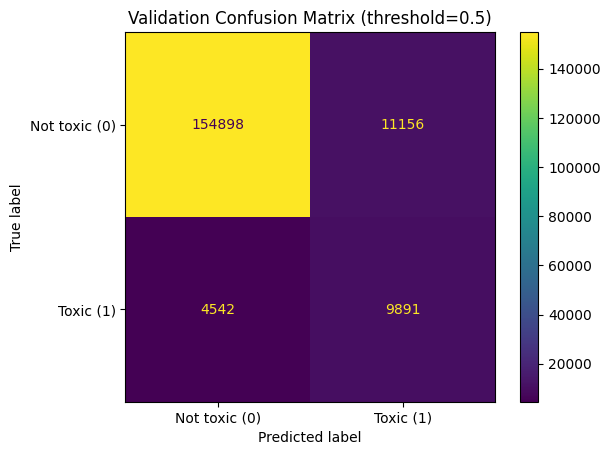

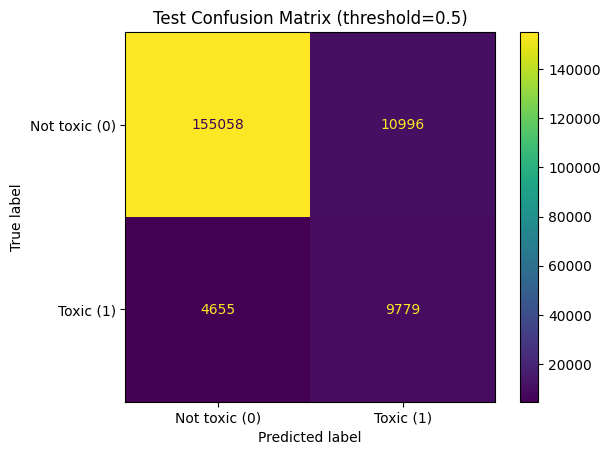

In [15]:
# import the confusion matrix function
from sklearn.metrics import confusion_matrix

# import the display helper for plotting the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# import matplotlib for showing the plots
import matplotlib.pyplot as plt

# set the threshold for turning probabilities into class labels
thr = 0.5

# chooses which validation probabilities to use
# if calibrated probabilities exist, use them
# otherwise use the baseline probabilities
if "val_prob_cal" in globals():
    val_probs_to_use = val_prob_cal
else:
    val_probs_to_use = val_prob

# chooses which test probabilities to use
# if calibrated probabilities exist, use them
# otherwise use the baseline probabilities
if "test_prob_cal" in globals():
    test_probs_to_use = test_prob_cal
else:
    test_probs_to_use = test_prob

# get the true validation labels from the validation dataframe
y_val_true = df_val["y"].values

# get the true test labels from the test dataframe
y_test_true = df_test["y"].values

# convert validation probabilities into 0 or 1 predictions using the threshold
y_val_pred = (val_probs_to_use >= thr).astype(int)

# convert test probabilities into 0 or 1 predictions using the threshold
y_test_pred = (test_probs_to_use >= thr).astype(int)

# build the validation confusion matrix
cm_val = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1])

# build the test confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred, labels=[0, 1])

# create the validation confusion matrix display object
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)

# plot the validation confusion matrix
disp_val.plot(values_format="d")

# add a title to the validation plot
plt.title(f"Validation Confusion Matrix (threshold={thr})")

# show the validation plot
plt.show()

# create the test confusion matrix display object
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)

# plot the test confusion matrix
disp_test.plot(values_format="d")

# add a title to the test plot
plt.title(f"Test Confusion Matrix (threshold={thr})")

# show the test plot
plt.show()

In [16]:
# import pandas so we can build the results table
import pandas as pd

# import confusion_matrix from sklearn
from sklearn.metrics import confusion_matrix

# set the decision threshold
# any probability greater than or equal to 0.5 becomes class 1
thr = 0.5

# list the identity columns we want to check
KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

# turn validation probabilities into 0 or 1 predictions
y_val_pred = (val_prob >= thr).astype(int)

# turn test probabilities into 0 or 1 predictions
y_test_pred = (test_prob >= thr).astype(int)

# create an empty list to store the subgroup results
rows = []

# create an empty dictionart to store validation confusion matrices later
val_cms = {}

# loop through each identity group
for col in KEY_IDS:

    # make a mask for validation rows where this identity equals 1
    val_mask = df_val[col].to_numpy() == 1

    # make a mask for test rows where this identity equals 1
    test_mask = df_test[col].to_numpy() == 1

    # count how many rows are in the validation subgroup
    n_val = int(val_mask.sum())

    # count how many rows are in the test subgroup
    n_test = int(test_mask.sum())

    # check whether the validation subgroup has any rows
    if n_val > 0:
        # build the confusion matrix for the validation subgroup
        cm_val = confusion_matrix(df_val["y"][val_mask], y_val_pred[val_mask], labels=[0, 1])

        # store the validation confusion matrix in the dictionary
        val_cms[col] = cm_val

        # unpack the confusion matrix into tn, fp, fn, tp
        tn_val, fp_val, fn_val, tp_val = cm_val.ravel()

        # calculate validation false positive rate
        # this is fp divided by all actual negatives
        if (fp_val + tn_val) > 0:
            val_fpr = fp_val / (fp_val + tn_val)
        else:
            val_fpr = float("nan")
    else:
        # if there are no rows, store missing values
        cm_val = None
        val_fpr = float("nan")

    # check whether the test subgroup has any rows
    if n_test > 0:
        # build the confusion matrix for the test subgroup
        cm_test = confusion_matrix(df_test["y"][test_mask], y_test_pred[test_mask], labels=[0, 1])

        # unpack the confusion matrix into tn, fp, fn, tp
        tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

        # calculate test false positive rate
        # this is fp divided by all actual negatives
        if (fp_test + tn_test) > 0:
            test_fpr = fp_test / (fp_test + tn_test)
        else:
            test_fpr = float("nan")
    else:
        # if there are no rows, store a missing value
        test_fpr = float("nan")

    # add one row of results for this subgroup
    rows.append({
        "identity": col,
        "n_val": n_val,
        "val_FPR": val_fpr,
        "n_test": n_test,
        "test_FPR": test_fpr
    })

# turn the list of rows into a dataframe
df_fpr = pd.DataFrame(rows)

# sort the table by validation FPR from highest to lowest
df_fpr = df_fpr.sort_values("val_FPR", ascending=False)

# print the threshold used
print("Threshold:", thr)

# print a title for the table
print("\nIdentity-slice False Positive Rate (FPR) where identity == 1")

# print the table with FPR values shown to 4 decimal places
print(
    df_fpr.to_string(
        index=False,
        formatters={
            "val_FPR": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "test_FPR": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
        },
    )
)

# get the subgroup with the highest validation FPR
worst_group = df_fpr.iloc[0]["identity"]

# get the highest validation FPR value
worst_val_fpr = df_fpr.iloc[0]["val_FPR"]

# print a simple summary sentence
print(f"\nHighest validation FPR was found in the '{worst_group}' subgroup (val_FPR={worst_val_fpr:.4f}).")

Threshold: 0.5

Identity-slice False Positive Rate (FPR) where identity == 1
                 identity  n_val val_FPR  n_test test_FPR
                    black   1553  0.4770    1526   0.4588
homosexual_gay_or_lesbian   1061  0.3651    1102   0.3449
                   muslim   2085  0.3486    2124   0.3683
                     male   4458  0.2305    4454   0.2254
                   female   5419  0.1972    5376   0.1926
                christian   4074  0.0975    4089   0.0931

Highest validation FPR was found in the 'black' subgroup (val_FPR=0.4770).


Reduced rate

In [17]:
from sklearn.model_selection import train_test_split

# make one shared reduced training subset from the full training split
df_train_sub, _ = train_test_split(
    df_train,
    train_size=100000,   # change this if needed
    stratify=df_train["y"],
    random_state=42
)

# reset index for cleanliness
df_train_sub = df_train_sub.reset_index(drop=True)

print("full train:", len(df_train))
print("shared train subset:", len(df_train_sub))
print("val:", len(df_val))
print("test:", len(df_test))
print(df_train_sub["y"].value_counts(normalize=True))

full train: 1443899
shared train subset: 100000
val: 180487
test: 180488
y
0    0.92003
1    0.07997
Name: proportion, dtype: float64


In [18]:
X_train = df_train_sub["comment_text"].values
y_train = df_train_sub["y"].values

In [19]:
X_val   = df_val["comment_text"].values
y_val   = df_val["y"].values

X_test  = df_test["comment_text"].values
y_test  = df_test["y"].values

In [20]:
# extract text and labels from the shared subset
X_train = df_train_sub["comment_text"].values
y_train = df_train_sub["y"].values

X_val   = df_val["comment_text"].values
y_val   = df_val["y"].values

X_test  = df_test["comment_text"].values
y_test  = df_test["y"].values


*   Validation (10%) - data kept aside whilst developing the model - use it to make decisions such as choosing settings or thresholds

*   Test set (10%)- data kept aside not used for decisions - check at the end to confirm final choice still works on unseen data

*   Training set (80%) - data the model learns from








*   n_val - how many times identity is mentioned in the validation set (1553 comments where 'black' is mentioned)
*   val_FPR - false positive rate in the validation set (0.5614 in the validation comments which mention 'black' are actually not toxic - 56% got wrongly flagged as toxic)


*   n_test - how many times identity is mentioned in the test set
*   test_FPR - false positive rate in the test set





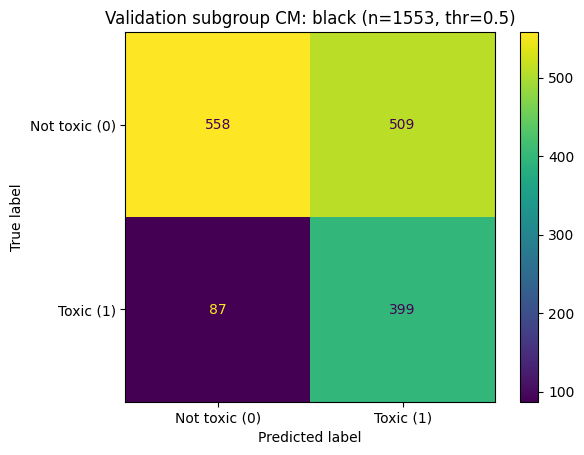

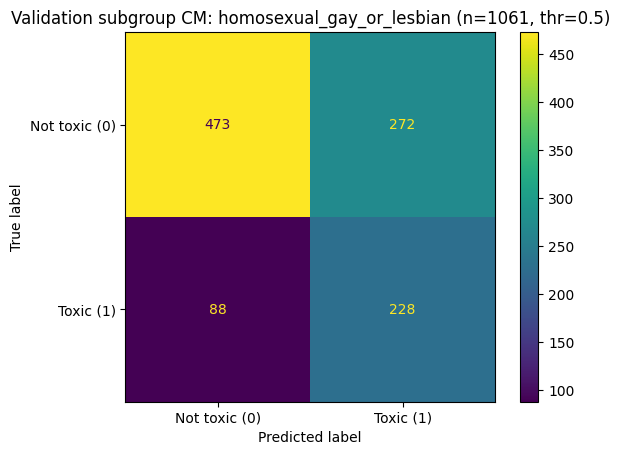

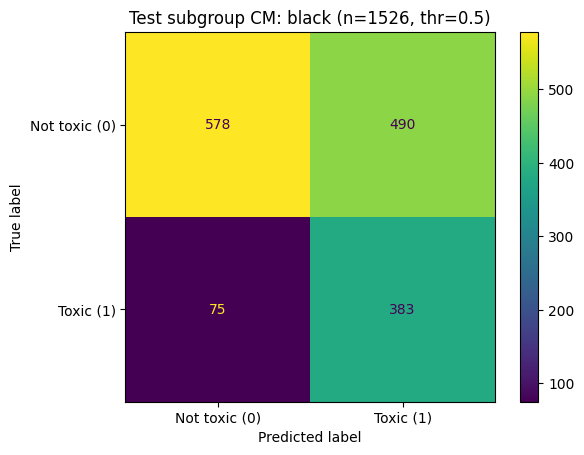

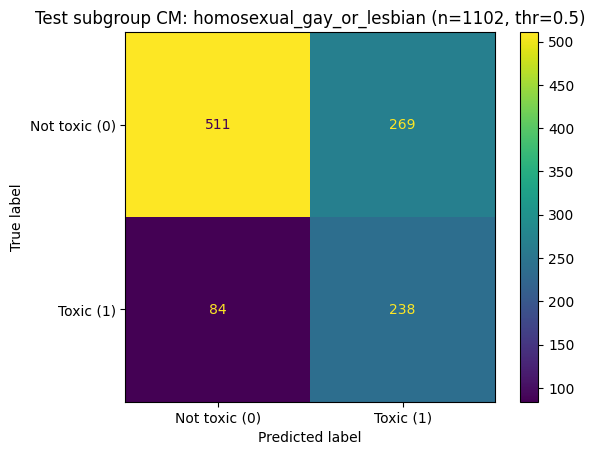

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

thr = 0.5 # anything above is toxic

y_val_true = df_val["y"].values
y_test_true = df_test["y"].values
y_val_pred = (val_prob >= thr).astype(int)
y_test_pred = (test_prob >= thr).astype(int)

def plot_identity_cm(df_split, y_true, y_pred, identity_col, title_prefix):
    mask = (df_split[identity_col].values == 1)
    if mask.sum() == 0:
        print(f"{identity_col}: no rows")
        return
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not toxic (0)", "Toxic (1)"])
    disp.plot(values_format="d")
    plt.title(f"{title_prefix}: {identity_col} (n={mask.sum()}, thr={thr})")
    plt.show()

# plot the top 2 worst groups from table
worst_ids = df_fpr.head(2)["identity"].tolist()

for col in worst_ids:
    plot_identity_cm(df_val, y_val_true, y_val_pred, col, "Validation subgroup CM")

for col in worst_ids:
    plot_identity_cm(df_test, y_test_true, y_test_pred, col, "Test subgroup CM")

0.94 AUC - if given one toxic comment and one-non toxic comment the model will rank the toxic one higher about 94% of the time

# SECTION 3.1 - Subgroup bias metrics table (Subgroup AUC, BPSN AUC, BNSP AUC)

Checks how well model works for each identity group

Finds the groups where performance is worst

Uses three fairness metrics: subgroup auc, bpsn auc, bnsp auc

Outputs a table so can report worst-group results

In [22]:
# subgroup bias metrics table (subgroup auc, bpsn auc, bnsp auc)

from sklearn.metrics import roc_auc_score
# auc measures how well the model separates toxic vs not toxic using probabilities
# basically checks how well the model separates toxic and not toxic

def safe_auc(y_true, y_score):
  # auc only works if both classes (0 and 1) present
  # if a subgroup has only 0s or only 1s, auc cannot be calculated

    if len(np.unique(y_true)) < 2:
        return np.nan
         # return "not a number" to show the metric is not available
    return roc_auc_score(y_true, y_score)

def subgroup_auc(df_split, y_prob, identity_col):
  # subgroup auc = auc only within the identity group
  # check how the model performs only for this identity group

    m = df_split[identity_col].values == 1
    return safe_auc(df_split.loc[m, "y"].values, y_prob[m])

def bpsn_auc(df_split, y_prob, identity_col):
  # test toxic outside group + non-toxic inside group
  # helps detect bias against this identity

    s = df_split
    mask = ((s[identity_col] == 1) & (s["y"] == 0)) | ((s[identity_col] == 0) & (s["y"] == 1))
    return safe_auc(s.loc[mask, "y"].values, y_prob[mask])

def bnsp_auc(df_split, y_prob, identity_col):
    # test toxic inside group + non-toxic outside group
    # checks if the model underestimates toxicity for this group

    s = df_split
    mask = ((s[identity_col] == 1) & (s["y"] == 1)) | ((s[identity_col] == 0) & (s["y"] == 0))
    return safe_auc(s.loc[mask, "y"].values, y_prob[mask])

# build results table for each identity group
rows = []
for col in IDENTITY_COLS:

  # count how many validation rows mention this identity
    n = int(df_val[col].sum())

    # skip identities with too few examples because metrics become unstable
    if n < 100:
        continue
    rows.append({
        "identity": col,
        "n_val": n,
        "subgroup_auc": subgroup_auc(df_val, val_prob, col),
        "bpsn_auc": bpsn_auc(df_val, val_prob, col),
        "bnsp_auc": bnsp_auc(df_val, val_prob, col),
      # store all metrics for this identity so we can compare later
    })

subgroup_table_val = pd.DataFrame(rows).sort_values("subgroup_auc")
# turn results into a dataframe and sort so worst subgroup auc appears first

print("Worst 10 identities by Subgroup AUC (val):")
subgroup_table_val.head(10)
# show the 10 weakest-performing identity groups


Worst 10 identities by Subgroup AUC (val):


,identity,n_val,subgroup_auc,bpsn_auc,bnsp_auc
4,homosexual_gay_or_lesbian,1061,0.748571,0.720987,0.936686
3,heterosexual,129,0.751792,0.701867,0.934574
9,black,1553,0.758135,0.663551,0.953859
7,muslim,2085,0.786448,0.732645,0.943463
10,white,2523,0.795134,0.659325,0.970762
8,atheist,163,0.796418,0.875841,0.858501
2,transgender,248,0.810440,0.826602,0.905336
6,jewish,765,0.819228,0.830462,0.910349
11,asian,470,0.827997,0.866119,0.881044
12,latino,187,0.852151,0.830352,0.923942


# AUC - homosexual_gay_or_lesbian → 0.769


*   Inside this group, performance drops compared to your overall AUC (0.94). So the model works worse for this group.

# BPSN_AUC


*   black -0.735 which is relatively low. Suggests the model may sometimes give high toxic scores to harmless comments mentioning black identity. Could mean possible bias.



# BNSP_AUC
*   Most are between 0.94 and 0.97 therefore the model generally detects toxic comments about groups fairly well.






AUC - How well does a model seperate toxic and non-toxic comments

*   (Higher the number the better) 1.0 is perfect, 0.5 is random guessing




Subgroup AUC - How well does the model work only inside this identity group e.g only comments mentioning Muslim
*   If subgroup AUC is low the model struggles specifically for that group




BPSN AUC - Background Positive, Subgroup Negative


*   Compare toxic comments NOT mentioning the group vs non-toxic comments mentioning the group
*   If the mdoel is biased it might unfairly label non-toxic comments about that group as toxic


*   IF BPSN is low the model may over-score harmless comments about that identity





BNSP AUC - Background Negative, Subgroup Positive


*   Compares toxic comments mentioning the group vs non-toxic comments not mentioning the group
*   If BNSP is low the modelmight miss toxic comments aimed at that identity



Some identity groups have lower performance than others

Homosexual_gay_or_lesbian group has the lowest subgroup auc (~0.77)

Heterosexual group also shows relatively low performance

Black group has lower bpsn auc (~0.73), suggesting possible over-prediction

Overall baseline looks strong, but fairness gaps clearly exist

Model performance is not equal across identity groups

# SECTION 4 – Calibration + ECE

In [23]:
val_prob = tfidf_lr.predict_proba(X_val)[:, 1]
# get the model's predicted probability of being toxic (class 1)
# for every validation comment

In [24]:
val_prob[:10]
# show the first 10 predicted probabilities
# this shows what confidence scores the model is giving

array([0.20966374, 0.29567607, 0.14588638, 0.1767033 , 0.35851959,
       0.36176628, 0.21904004, 0.51949713, 0.09644627, 0.29412216])

In [25]:
print(val_prob.min(), val_prob.max())
# show the lowest and highest predicted probabilities
# helps check the range of model confidence (from near 0 to near 1)

0.005919722875358672 0.9999997722718564




*   First few comments have low probabillity such as 0.02 or 0.06, model thinks they are likely non-toxic
*   Example being 0.915 meaning the model is very confidence that it is toxic


*   Min is 0.001 meaning the model is extremely confident some comments are non-toxic
*   Max is 0.999999 meaning that the model is extremely confident some comments are toxic





Validation ECE (10 bins): 0.16493306068312313


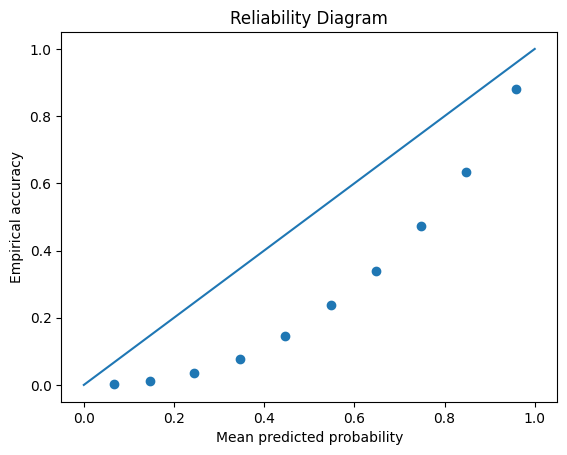

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def ece_score(y_true, y_prob, n_bins=10):
  # ece shows how far the model's probabilities are from reality
  # lower ece = better calibrated probabilities

    bins = np.linspace(0, 1, n_bins + 1)
    # split 0 to 1 into equal ranges (bins)

    bin_ids = np.digitize(y_prob, bins) - 1
    # assign each prediction to a bin based on its probability

    ece = 0.0
    # add up the calibration error across bins

    for b in range(n_bins):
      # look at one bin at a time

        mask = bin_ids == b
        # mask selects the samples that fall into this bin

        if mask.sum() == 0:
          # skip empty bins

            continue
        acc = y_true[mask].mean()
        # actual toxic rate inside this bin (what really happened)

        conf = y_prob[mask].mean()
        # average predicted probability inside this bin (what the model claimed)

        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
         # add weighted difference between reality and prediction

    return ece
    # final ece score

def plot_reliability(y_true, y_prob, n_bins=10):
  # reliability diagram shows calibration visually
    # perfect calibration would sit on the diagonal line

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    xs, ys = [], []
    # xs will store average predicted probability per bin
    # ys will store actual toxic rate per bin

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        xs.append(y_prob[mask].mean())
        # x-axis: what the model predicted on average

        ys.append(y_true[mask].mean())
         # y-axis: what actually happened

    plt.figure()
    plt.plot([0,1],[0,1])
    # diagonal line = perfect calibration

    plt.scatter(xs, ys)
    # points show each bin's prediction vs reality
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Empirical accuracy")
    plt.title("Reliability Diagram")
    plt.show()

print("Validation ECE (10 bins):", ece_score(y_val, val_prob))
# print calibration error on validation set

plot_reliability(y_val, val_prob)
# draw the reliability diagram


ECE - Expected Calibration Error


*   Says on average, how far is the model's confidence from what really happened.



*   ECE is around 0.142 - on average the model's predicted probabilities are off by around 14% from reality


*   Quite high - model is good at ranking, but not very good at well calibrated -mpdel is over confident










*   Bins are probability ranges - 0.0-0.1, 0.1-0.2, 0.2-0.3, 0.3-0.4, 0.4-0.5. 0.5-0.6, 0.6-0.7, 0.7-0.8, 0.8-0.9, 0.9-0.10
*   Mask is a way to select certain rows e.g mask = y_prob > 0.5 means to select only rows where the probability is greater than 0.5


*   xs is average predicted probaility in each bin
*   ys is actual toxic rate in each bin






Measured calibration using ece on validation predictions

Ece around 0.142, suggesting probabilities are poorly calibrated

Reliability diagram shows over-confidence (points below diagonal)

Motivates applying probability calibration (platt scaling or isotonic) before thresholding and fairness constraints

# SECTION 5 - Probability Calibration (Isotonic)

In [27]:
from sklearn.calibration import CalibratedClassifierCV
# tool used to adjust (calibrate) probability outputs
from sklearn.metrics import roc_auc_score
# used to measure ranking performance (AUC)

# get the already trained tf-idf vectorizer and logistic regression
tfidf = tfidf_lr.named_steps["tfidf"]
lr = tfidf_lr.named_steps["lr"]

# convert text into tf-idf features manually
# fit on training set only
X_train_vec = tfidf.fit_transform(X_train)


# transform validation and test sets using the same vocab
X_val_vec   = tfidf.transform(X_val)
# takes the raw text, turns it into numbers, uses the same word style learned from training

# fit - learn vocab from training text
# transform - turn new text into numbers using that vocab

X_test_vec  = tfidf.transform(X_test)

# train logistic regression again on vectorised training data
lr.fit(X_train_vec, y_train)

# apply isotonic calibration using validation data
# this adjusts the probability outputs to better match reality
cal = CalibratedClassifierCV(lr, method="isotonic", cv="prefit")

# fit calibration model on validation data
cal.fit(X_val_vec, y_val)

# get new calibrated probabilities
val_prob_cal  = cal.predict_proba(X_val_vec)[:, 1]
test_prob_cal = cal.predict_proba(X_test_vec)[:, 1]

# check if AUC changed after calibration
print("AUC (val, calibrated): ", roc_auc_score(y_val, val_prob_cal))
print("AUC (test, calibrated):", roc_auc_score(y_test, test_prob_cal))


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


AUC (val, calibrated):  0.912945450373098
AUC (test, calibrated): 0.9110668154364625




*   Vectorised data - text turned into numerical format (text converted into numbers so the model can use it)
*   Isotonic Calibration - model outpuits probabilities, calibration adjusts the numvbers so that if the model says 80, it would really mean 80% in real life (smooth curve which fixes the probability scale)

*   Emprical (what actually happened)



*   Calibration model takes the raw probabilities (oringal model) learns how wrong they are, anf then corrects them.









# Validation set - used to tune model settings, tune thresholds, fit calibration

ECE before: 0.16493306068312313
ECE after : 7.42905346015153e-18


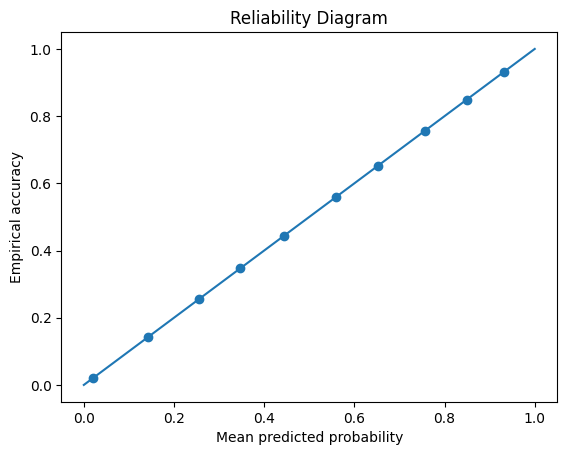

In [28]:
print("ECE before:", ece_score(y_val, val_prob))
# compute calibration error before applying isotonic calibration
# this measures how far model confidence was from reality

print("ECE after :", ece_score(y_val, val_prob_cal))
# compute calibration error after isotonic calibration
# this shows how much calibration improved probability accuracy

plot_reliability(y_val, val_prob_cal)
# draw reliability diagram using calibrated probabilities
# checks how well predicted confidence matches actual outcomes

Validation set:

Used to TRAIN the calibration curve - learned directly from the data so it can match the data almost perfectly

So calibration fits this data very closely therefore ECE ≈ 0 (almost perfect)

# Test set - used to learn model weights

Test ECE (calibrated): 0.001530746840694725


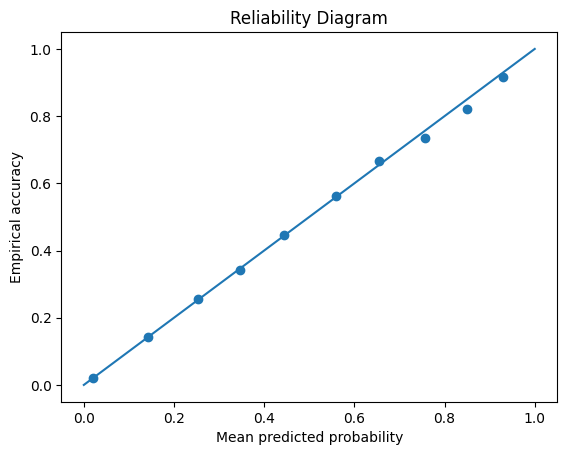

In [29]:
print("Test ECE (calibrated):", ece_score(y_test, test_prob_cal))
# compute calibration error on completely unseen test data
# this checks if calibration generalises beyond validation data

plot_reliability(y_test, test_prob_cal)
# draw reliability diagram for test predictions
# visual check that probabilities match real outcomes

Test set:

Never seen during calibration

Used to check if calibration truly works - ECE ≈ 0.0022

That means calibration generalises extremely well - correction learned on validation meaning that it works on completely unseen data

# SECTION 6 - Constrained threshold search

In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np

def subgroup_fpr(df_split, y_prob, thr, identity):
    mask = (df_split[identity].values == 1)
    # select only rows that belong to this identity group (eg muslim == 1)

    if mask.sum() == 0:
      # if this group has no rows, cannot compute anything
        return np.nan

    y_true = df_split.loc[mask, "y"].values
    # true labels (0 not toxic, 1 toxic) for this identity group

    y_pred = (y_prob[mask] >= thr).astype(int)
    # turn probabilities into hard predictions using the threshold:
    # if prob >= thr -> predict toxic (1), else non-toxic (0)


    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    # build a 2x2 confusion matrix and unpack it into tn/fp/fn/tp

    denom = fp + tn
    # total number of truly non-toxic comments in this subgroup

    return fp / denom if denom > 0 else np.nan
    # false positive rate = out of the non-toxic ones, how many got wrongly flagged toxic



*   FPR - False Positive Rate - Number of wrongly flagged toxic / total truly non-toxic
*   Tries differen thresholds, checks how fiarness changes in each group, sees if one group is being falsely flagged more than others





*   Defines subgroup False Positive Rate (FPR)
*   Checks one identity group at a time


*   Uses the threshold to make final predictions
*   Builds a confusion matrix for that subgroup


*   Calculates how often non-toxic comments are wrongly flagged toxic
*   Helps compare fairness across different groups

*   Used during threshold search to reduce unfair over-flagging









## Threshold search on validation set

In [31]:
# import pandas to store the threshold results in a table
import pandas as pd

# import numpy for making the list of thresholds
import numpy as np

# import precision, recall and f1 to ompare thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

# choose the identity groups to monitor during threshold search
KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

# use calibrated validation probabilities if they exist
# otherwise use the original validation probabilities
if "val_prob_cal" in globals():
    val_prob_used = val_prob_cal
else:
    val_prob_used = val_prob

# get the true validation labels
y_val_true = df_val["y"].values

# set the fairness target for the worst subgroup false positive rate
max_allowed_fpr = 0.15

# set the minimum recall target
min_required_recall = 0.80

# create a list of thresholds to test
thresholds = np.arange(0.05, 0.96, 0.01)

# create an empty list to store one row of results per threshold
search_rows = []

# loop through each threshold
for thr in thresholds:

    # turn validation probabilities into final 0 or 1 predictions
    y_val_pred = (val_prob_used >= thr).astype(int)

    # calculate overall precision on the validation set
    val_precision = precision_score(y_val_true, y_val_pred, zero_division=0)

    # calculate overall recall on the validation set
    val_recall = recall_score(y_val_true, y_val_pred, zero_division=0)

    # calculate overall f1 on the validation set
    val_f1 = f1_score(y_val_true, y_val_pred, zero_division=0)

    # create an empty dictionary to store subgroup FPR values for this threshold
    subgroup_fprs = {}

    # loop through each identity group
    for identity in KEY_IDS:

        # calculate subgroup FPR for this identity at the current threshold
        subgroup_fprs[identity] = subgroup_fpr(df_val, val_prob_used, thr, identity)

    # turn subgroup FPR values into a pandas series for easier analysis
    fpr_series = pd.Series(subgroup_fprs, dtype="float64")

    # get the highest subgroup FPR at this threshold
    worst_fpr = fpr_series.max()

    # get the identity group with the highest subgroup FPR
    worst_group = fpr_series.idxmax()

    # check whether this threshold passes both constraints
    passes_constraints = (worst_fpr <= max_allowed_fpr) and (val_recall >= min_required_recall)

    # store the results for this threshold
    search_rows.append({
        "threshold": thr,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "worst_group": worst_group,
        "worst_val_fpr": worst_fpr,
        "passes_constraints": passes_constraints
    })

# turn the results into a dataframe
df_threshold_search = pd.DataFrame(search_rows)

# show the first few rows
df_threshold_search.head()

,threshold,val_precision,val_recall,val_f1,worst_group,worst_val_fpr,passes_constraints
0,0.05,0.257770,0.875702,0.398298,black,0.740394,False
1,0.06,0.276750,0.859627,0.418703,black,0.721649,False
2,0.07,0.302396,0.838634,0.444510,black,0.688847,False
3,0.08,0.321225,0.823460,0.462164,black,0.673852,False
4,0.09,0.336257,0.810227,0.475269,black,0.650422,False




*   Testing multiple thresholds from 0.05-0.95
*   For each threshold, turning model probabilities into final toxic / non-toxic predictions


*   Calculating subgroup FPR for each identity group using  subgroup_fpr(...) function
*   Finding the worst subgroup at that threshold




At very low thresholds, the model catches a lot of toxic comments, so recall is high but it also wrongly flags lots of non-toxic comments, especially for the worst subgroup so fairness is poor at these low thresholds.

Citations


*   https://scikit-learn.org/stable/modules/classification_threshold.html
*   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html




## Choose the best threshold

In [32]:
# keep only thresholds that pass the fairness and recall rules
valid_thresholds = df_threshold_search[df_threshold_search["passes_constraints"] == True].copy()

# check whether any threshold passed the rules
if len(valid_thresholds) > 0:

    # sort valid thresholds by best f1 first, then lowest worst subgroup fpr
    valid_thresholds = valid_thresholds.sort_values(
        ["val_f1", "worst_val_fpr"],
        ascending=[False, True]
    )

    # take the best valid threshold
    best_row = valid_thresholds.iloc[0]

    # save the chosen threshold
    best_thr = float(best_row["threshold"])

    # print a message showing that a valid threshold was found
    print("A threshold meeting the constraints was found.")
else:

    # if no threshold passed, choose the one with the lowest worst subgroup fpr
    fallback_thresholds = df_threshold_search.sort_values(
        ["worst_val_fpr", "val_f1"],
        ascending=[True, False]
    )

    # take the best fallback threshold
    best_row = fallback_thresholds.iloc[0]

    # save the chosen threshold
    best_thr = float(best_row["threshold"])

    # print a message showing that no threshold passed and a fallback was used
    print("No threshold met all constraints, so the lowest worst-group FPR threshold was chosen.")

# print the chosen threshold
print("Chosen threshold:", round(best_thr, 2))

# print the validation precision at the chosen threshold
print("Validation precision:", round(float(best_row["val_precision"]), 4))

# print the validation recall at the chosen threshold
print("Validation recall:", round(float(best_row["val_recall"]), 4))

# print the validation f1 at the chosen threshold
print("Validation F1:", round(float(best_row["val_f1"]), 4))

# print the worst subgroup at the chosen threshold
print("Worst subgroup:", best_row["worst_group"])

# print the worst subgroup validation fpr at the chosen threshold
print("Worst subgroup validation FPR:", round(float(best_row["worst_val_fpr"]), 4))

No threshold met all constraints, so the lowest worst-group FPR threshold was chosen.
Chosen threshold: 0.93
Validation precision: 0.9767
Validation recall: 0.0378
Validation F1: 0.0728
Worst subgroup: homosexual_gay_or_lesbian
Worst subgroup validation FPR: 0.0013




1.   Looks at the threshold search results table
2.   Checks whether any threshold passed your fairness and recall rules, if yes it picks the one with the best F1 score


1.   If no threshold passed, it picks the one with the lowest worst-group FPR instead
2.   Prints the final chosen threshold and its validation results




1.   Then says which supgroup was worst affected at that chosen threshold









Precision = when the model says something is toxic, how often is it actually right

Recall = out of all the toxic comments that really exist, how many did the model successfully catch

F1 score = one combined score that balances precision and recall

High precision means fewer innocent comments are wrongly flagged

High recall means fewer toxic comments are missed

F1 helps judge the overall balance between both

## Show the best thresholds table


In [33]:
# sort all thresholds by best f1 and then lowest worst subgroup fpr
top_thresholds = df_threshold_search.sort_values(
    ["passes_constraints", "val_f1", "worst_val_fpr"],
    ascending=[False, False, True]
).head(10)

# print a title
print("Top threshold candidates on validation set")

# print the table nicely
print(
    top_thresholds.to_string(
        index=False,
        formatters={
            "threshold": lambda x: f"{x:.2f}",
            "val_precision": lambda x: f"{x:.4f}",
            "val_recall": lambda x: f"{x:.4f}",
            "val_f1": lambda x: f"{x:.4f}",
            "worst_val_fpr": lambda x: f"{x:.4f}"
        }
    )
)

Top threshold candidates on validation set
threshold val_precision val_recall val_f1 worst_group worst_val_fpr  passes_constraints
     0.28        0.5732     0.5787 0.5759       black        0.3421               False
     0.29        0.5732     0.5787 0.5759       black        0.3421               False
     0.27        0.5627     0.5891 0.5756       black        0.3543               False
     0.30        0.5947     0.5573 0.5754       black        0.3215               False
     0.31        0.5947     0.5573 0.5754       black        0.3215               False
     0.32        0.5979     0.5539 0.5751       black        0.3177               False
     0.33        0.5979     0.5539 0.5751       black        0.3177               False
     0.25        0.5169     0.6394 0.5717       black        0.4161               False
     0.26        0.5169     0.6394 0.5717       black        0.4161               False
     0.22        0.5166     0.6397 0.5716       black        0.4161          

The best F1 values are around thresholds like 0.32, 0.33, 0.34

These thresholds give a much better balance than 0.93

They still do not pass fairness rule, because passes_constraints is False

The black subgroup is still the worst affected in these top rows

These thresholds are stronger for performance, but still not fair enough under your chosen constraint

Worst subgroup FPR <= 0.15


*   The most unfairly affected identity group must have false positive rate no higher than 15%

Validation recall >= 0.80


*   The model must still catch at least 80% of the toxic comments in the validation set

## Evaluate before vs after on validation and test

In [34]:
# import the confusion matrix function
from sklearn.metrics import confusion_matrix

# use calibrated test probabilities if they exist
# otherwise use the original test probabilities
if "test_prob_cal" in globals():
    test_prob_used = test_prob_cal
else:
    test_prob_used = test_prob

# get the true test labels
y_test_true = df_test["y"].values

# create predictions using the original 0.50 threshold on validation
y_val_pred_050 = (val_prob_used >= 0.50).astype(int)

# create predictions using the chosen threshold on validation
y_val_pred_best = (val_prob_used >= best_thr).astype(int)

# create predictions using the original 0.50 threshold on test
y_test_pred_050 = (test_prob_used >= 0.50).astype(int)

# create predictions using the chosen threshold on test
y_test_pred_best = (test_prob_used >= best_thr).astype(int)

# create a helper function to calculate overall metrics
def overall_metrics(y_true, y_pred):

    # build the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # calculate precision
    precision = precision_score(y_true, y_pred, zero_division=0)

    # calculate recall
    recall = recall_score(y_true, y_pred, zero_division=0)

    # calculate f1
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # calculate false positive rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    # calculate false negative rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    # return all metrics in a dictionary
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# calculate validation metrics at 0.50
val_metrics_050 = overall_metrics(y_val_true, y_val_pred_050)

# calculate validation metrics at chosen threshold
val_metrics_best = overall_metrics(y_val_true, y_val_pred_best)

# calculate test metrics at 0.50
test_metrics_050 = overall_metrics(y_test_true, y_test_pred_050)

# calculate test metrics at chosen threshold
test_metrics_best = overall_metrics(y_test_true, y_test_pred_best)

# build a comparison table
df_overall_compare = pd.DataFrame([
    {"split": "validation", "threshold": 0.50, **val_metrics_050},
    {"split": "validation", "threshold": best_thr, **val_metrics_best},
    {"split": "test", "threshold": 0.50, **test_metrics_050},
    {"split": "test", "threshold": best_thr, **test_metrics_best}
])

# print the comparison table
print(
    df_overall_compare.to_string(
        index=False,
        formatters={
            "threshold": lambda x: f"{x:.2f}",
            "precision": lambda x: f"{x:.4f}",
            "recall": lambda x: f"{x:.4f}",
            "f1": lambda x: f"{x:.4f}",
            "fpr": lambda x: f"{x:.4f}",
            "fnr": lambda x: f"{x:.4f}"
        }
    )
)

     split threshold precision recall     f1    fpr    fnr     tn   fp    fn   tp
validation      0.50    0.7488 0.3916 0.5143 0.0114 0.6084 164158 1896  8781 5652
validation      0.93    0.9767 0.0378 0.0728 0.0001 0.9622 166041   13 13887  546
      test      0.50    0.7395 0.3876 0.5086 0.0119 0.6124 164083 1971  8840 5594
      test      0.93    0.9677 0.0374 0.0720 0.0001 0.9626 166036   18 13894  540


At threshold 0.50 on test:



*   fn = 7248
*   fnr = 0.5021

Meaning:



*   The model missed 7,248 toxic comments


*   It missed about 50.21% of the toxic comments



At threshold 0.93 on test:

*   fn = 13135
*   fnr = 0.9100

Meaning:



*   The model missed 13,135 toxic comments
*   Missed about 91.00% of the toxic comments





Threshold reduces FPR rate but it increases FPR (False Negative Rate, toxic comments the model labels as non-toxic)

Split - whether the results are from validation or test

Threshold - the probability cut-off used to decide toxic vs non-toxic

Precision - when the model predicts toxic, how often it is correct

Recall - how many real toxic comments it catches

F1 - balance between precision and recall

FPR - how often non-toxic comments are wrongly flagged toxic

FNR - how often toxic comments are wrongly missed

TN, FP, FN, TP - confusion matrix counts

## Subgroup FPR table before vs after

In [35]:
# create an empty list to store subgroup results
subgroup_rows = []

# loop through each identity group
for identity in KEY_IDS:

    # calculate validation subgroup fpr at 0.50
    val_fpr_050 = subgroup_fpr(df_val, val_prob_used, 0.50, identity)

    # calculate validation subgroup fpr at chosen threshold
    val_fpr_best = subgroup_fpr(df_val, val_prob_used, best_thr, identity)

    # calculate test subgroup fpr at 0.50
    test_fpr_050 = subgroup_fpr(df_test, test_prob_used, 0.50, identity)

    # calculate test subgroup fpr at chosen threshold
    test_fpr_best = subgroup_fpr(df_test, test_prob_used, best_thr, identity)

    # store one row of subgroup results
    subgroup_rows.append({
        "identity": identity,
        "val_fpr_0.50": val_fpr_050,
        "val_fpr_best": val_fpr_best,
        "test_fpr_0.50": test_fpr_050,
        "test_fpr_best": test_fpr_best
    })

# turn the subgroup results into a dataframe
df_subgroup_compare = pd.DataFrame(subgroup_rows)

# sort by the highest validation fpr at 0.50
df_subgroup_compare = df_subgroup_compare.sort_values("val_fpr_0.50", ascending=False)

# print the subgroup comparison table
print(
    df_subgroup_compare.to_string(
        index=False,
        formatters={
            "val_fpr_0.50": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "val_fpr_best": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "test_fpr_0.50": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "test_fpr_best": lambda x: f"{x:.4f}" if pd.notna(x) else "nan"
        }
    )
)

                 identity val_fpr_0.50 val_fpr_best test_fpr_0.50 test_fpr_best
                    black       0.1649       0.0000        0.1573        0.0000
homosexual_gay_or_lesbian       0.1114       0.0013        0.0897        0.0000
                   muslim       0.0901       0.0000        0.0898        0.0000
                     male       0.0577       0.0000        0.0533        0.0000
                   female       0.0412       0.0000        0.0411        0.0000
                christian       0.0188       0.0000        0.0167        0.0000


Every subgroup had a lower FPR after switching to the chosen threshold.

The black subgroup had the highest FPR at 0.50 homosexual_gay_or_lesbian was also relatively high

After using the stricter threshold, subgroup FPR became almost zero for all groups so the threshold greatly reduced unfair false positives across groups

Identity - the subgroup being checked

val_fpr_0.50 - validation subgroup FPR at threshold 0.50

val_fpr_best - validation subgroup FPR at the chosen threshold

test_fpr_0.50 - test subgroup FPR at threshold 0.50

test_fpr_best - test subgroup FPR at the chosen threshold

## Final confusion matrix using chosen threshold

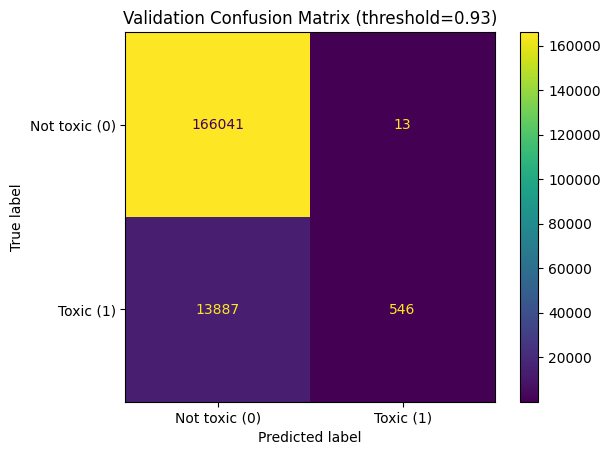

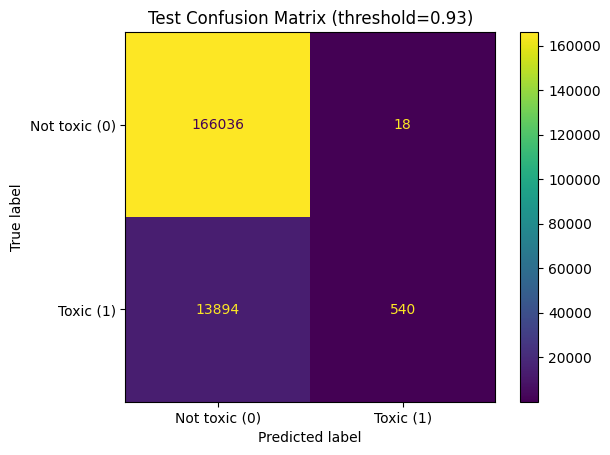

In [36]:
# import plotting tools
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# build the validation confusion matrix at the chosen threshold
cm_val_best = confusion_matrix(y_val_true, y_val_pred_best, labels=[0, 1])

# build the test confusion matrix at the chosen threshold
cm_test_best = confusion_matrix(y_test_true, y_test_pred_best, labels=[0, 1])

# create the validation confusion matrix display
disp_val_best = ConfusionMatrixDisplay(
    confusion_matrix=cm_val_best,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)

# plot the validation confusion matrix
disp_val_best.plot(values_format="d")

# add a title to the validation plot
plt.title(f"Validation Confusion Matrix (threshold={best_thr:.2f})")

# show the validation plot
plt.show()

# create the test confusion matrix display
disp_test_best = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_best,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)

# plot the test confusion matrix
disp_test_best.plot(values_format="d")

# add a title to the test plot
plt.title(f"Test Confusion Matrix (threshold={best_thr:.2f})")

# show the test plot
plt.show()

Top left = true negatives

*   Non-toxic comments correctly predicted as non-toxic

Top right = false positives

*   Non-toxic comments wrongly predicted as toxic

Bottom left = false negatives

*   Toxic comments wrongly predicted as non-toxic

Bottom right = true positives

*   Toxic comments correctly predicted as toxic



The model is now very cautious about calling comments toxic, it almost never falsely accuses non-toxic comments but it misses a large number of actual toxic comments.

### Model 2 - DistilBERT

In [37]:
# install the main libraries used in the official Hugging Face text classification workflow
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [38]:
# SECTION 4: TRANSFORMER-BASED MODEL (FINE-TUNING)
# this section follows the same overall structure as the text classification template:
# 1) prepare the data
# 2) tokenize it
# 3) load the model
# 4) define training settings
# 5) train
# 6) evaluate on held-out validation and test data
# 7) save the final model for the front end


# import pandas for table handling
import pandas as pd

# import numpy for arrays and maths
import numpy as np

# import torch because transformers uses pytorch underneath
import torch

# import Dataset so pandas dataframes can be turned into hugging face datasets
from datasets import Dataset

# import evaluate for standard text classification metrics
import evaluate

# import the tokenizer class loader
from transformers import AutoTokenizer

# import the model class loader for sequence classification
from transformers import AutoModelForSequenceClassification

# import a dynamic padding helper used during batching
from transformers import DataCollatorWithPadding

# import the Trainer API
from transformers import Trainer

# import training arguments for the Trainer
from transformers import TrainingArguments

# import sklearn metrics for extra evaluation
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

# set a fixed seed so the subset and training are reproducible
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# STEP 1: BUILD A SHARED 100K TRAINING SUBSET
# this keeps the transformer comparable with the baseline
# the baseline also used a stratified 100k training subset
# validation and test stay as the original held-out splits

from sklearn.model_selection import train_test_split

# create one shared stratified subset from the full training split
df_train_sub, _ = train_test_split(
    df_train,
    train_size=100000,
    stratify=df_train["y"],
    random_state=SEED
)

# reset the row index so later steps stay clean
df_train_sub = df_train_sub.reset_index(drop=True)

# print the final split sizes used in the transformer section
print("full train size:", len(df_train))
print("subset train size:", len(df_train_sub))
print("validation size:", len(df_val))
print("test size:", len(df_test))

# STEP 2: KEEP ONLY THE COLUMNS NEEDED FOR DISTILBERT
# train on the 100k subset
# evaluate on the full validation and full test splits

# keep only the text and label columns for the transformer model
train_small = df_train_sub[["comment_text", "y"]].copy()
val_small   = df_val[["comment_text", "y"]].copy()
test_small  = df_test[["comment_text", "y"]].copy()

# rename the label column to the standard hugging face name
train_small = train_small.rename(columns={"y": "label"})
val_small   = val_small.rename(columns={"y": "label"})
test_small  = test_small.rename(columns={"y": "label"})

# make sure the text column is stored as string
train_small["comment_text"] = train_small["comment_text"].astype(str)
val_small["comment_text"]   = val_small["comment_text"].astype(str)
test_small["comment_text"]  = test_small["comment_text"].astype(str)

# make sure the label column is integer
train_small["label"] = train_small["label"].astype(int)
val_small["label"]   = val_small["label"].astype(int)
test_small["label"]  = test_small["label"].astype(int)

# reset the row index so conversion is clean
train_small = train_small.reset_index(drop=True)
val_small   = val_small.reset_index(drop=True)
test_small  = test_small.reset_index(drop=True)

# turn the pandas dataframes into hugging face datasets
train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test_small)

# print the dataset sizes so i can confirm nothing is mixed up
print(train_ds)
print(val_ds)
print(test_ds)

# STEP 3: LOAD DISTILBERT TOKENIZER

# choose the compact transformer checkpoint
checkpoint = "distilbert-base-uncased"

# load the tokenizer for the chosen checkpoint
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# STEP 4: TOKENISE THE DATA
# this follows the same template logic:
# tokenize text -> remove raw text column -> set torch format

# create a tokenisation function
def tokenize_function(example):
    # convert raw text into token ids and attention masks
    return tokenizer(
        example["comment_text"],
        truncation=True,
        max_length=128
    )

# tokenise the training dataset
train_tok = train_ds.map(tokenize_function, batched=True)

# tokenise the validation dataset
val_tok = val_ds.map(tokenize_function, batched=True)

# tokenise the test dataset
test_tok = test_ds.map(tokenize_function, batched=True)

# remove the raw text column because the model only needs token inputs and labels
train_tok = train_tok.remove_columns(["comment_text"])
val_tok   = val_tok.remove_columns(["comment_text"])
test_tok  = test_tok.remove_columns(["comment_text"])

# tell the datasets to return pytorch tensors
train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")

# print lengths to confirm all objects match properly
print(len(train_small), len(train_tok))
print(len(val_small), len(val_tok))
print(len(test_small), len(test_tok))

# STEP 5: CREATE A DATA COLLATOR
# this pads each batch dynamically instead of padding everything to one fixed size

# create a data collator so batches are padded dynamically
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# STEP 6: LOAD METRICS

# load standard metrics from the evaluate library
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

# define a metrics function for Trainer evaluation
def compute_metrics(eval_pred):
    # unpack logits and true labels from the Trainer output
    logits, labels = eval_pred

    # convert logits into predicted class ids
    predictions = np.argmax(logits, axis=-1)

    # calculate accuracy
    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    # calculate precision for the toxic class
    precision = precision_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )

    # calculate recall for the toxic class
    recall = recall_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )

    # calculate f1 for the toxic class
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )

    # combine the metric values into one dictionary
    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"]
    }

# STEP 7: LOAD DISTILBERT FOR BINARY CLASSIFICATION

# load DistilBERT for binary sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# STEP 8: SET THE TRAINING CONFIGURATION
# this keeps the setup compact enough for colab while still evaluating regularly

# set the training configuration
training_args = TrainingArguments(
    output_dir="./distilbert_toxicity_model",
    eval_strategy="steps",
    save_strategy="steps",
    logging_strategy="steps",
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# STEP 9: CREATE THE TRAINER OBJECT

# create the Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# STEP 10: TRAIN THE MODEL

# train the DistilBERT model
trainer.train()

# STEP 11: RUN VALIDATION PREDICTION
# this creates validation probabilities for auc and later fairness analysis

# run prediction on the validation set
val_pred_output = trainer.predict(val_tok)

# extract the raw logits for validation
val_logits_bert = val_pred_output.predictions

# convert validation logits into predicted classes
val_pred_bert = np.argmax(val_logits_bert, axis=1)

# convert validation logits into probabilities for class 1
val_prob_bert = torch.softmax(
    torch.tensor(val_logits_bert), dim=1
)[:, 1].numpy()

# get the true validation labels
y_val_bert = np.array(val_small["label"])

# calculate validation roc-auc
val_auc_bert = roc_auc_score(y_val_bert, val_prob_bert)

# print the validation roc-auc
print("Validation ROC-AUC:", round(val_auc_bert, 4))

# STEP 12: RUN TEST PREDICTION
# this creates final test probabilities and predictions

# run prediction on the test set
test_pred_output = trainer.predict(test_tok)

# extract the raw logits for test
test_logits_bert = test_pred_output.predictions

# convert test logits into predicted classes
test_pred_bert = np.argmax(test_logits_bert, axis=1)

# convert test logits into probabilities for class 1
test_prob_bert = torch.softmax(
    torch.tensor(test_logits_bert), dim=1
)[:, 1].numpy()

# get the true test labels
y_test_bert = np.array(test_small["label"])

# calculate test roc-auc
test_auc_bert = roc_auc_score(y_test_bert, test_prob_bert)

# print the test roc-auc
print("Test ROC-AUC:", round(test_auc_bert, 4))

# STEP 13: CALCULATE EXTRA TEST METRICS
# this gives me the main classification metrics and confusion matrix

# calculate precision, recall and f1 on the test set
test_precision_bert, test_recall_bert, test_f1_bert, _ = precision_recall_fscore_support(
    y_test_bert,
    test_pred_bert,
    average="binary",
    zero_division=0
)

# build the test confusion matrix
cm_test_bert = confusion_matrix(y_test_bert, test_pred_bert, labels=[0, 1])

# print the main test metrics
print("Test precision:", round(test_precision_bert, 4))
print("Test recall:", round(test_recall_bert, 4))
print("Test F1:", round(test_f1_bert, 4))
print("Test confusion matrix:")
print(cm_test_bert)

# STEP 14: SAVE THE FINAL MODEL FOR THE FRONT END

# save the trained model
trainer.save_model("./distilbert_toxicity_model_final")

# save the tokenizer as well
tokenizer.save_pretrained("./distilbert_toxicity_model_final")

full train size: 1443899
subset train size: 100000
validation size: 180487
test size: 180488
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 100000
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 180487
})
Dataset({
    features: ['comment_text', 'label'],
    num_rows: 180488
})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Validation ROC-AUC: 0.9496


Test ROC-AUC: 0.9488
Test precision: 0.7063
Test recall: 0.6119
Test F1: 0.6557
Test confusion matrix:
[[162382   3672]
 [  5602   8832]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_toxicity_model_final/tokenizer_config.json',
 './distilbert_toxicity_model_final/tokenizer.json')

In [39]:
# import the extra sklearn metric i need for the classification report
from sklearn.metrics import classification_report

# ======================================================
# VALIDATION SET: PREDICTIONS + ROC-AUC
# this creates validation probabilities so i can measure
# how well the model separates toxic and non-toxic text
# ======================================================

# run prediction on the validation set
val_pred_output = trainer.predict(val_tok)

# extract the raw logits for validation
val_logits_bert = val_pred_output.predictions

# convert validation logits into predicted classes
val_pred_bert = np.argmax(val_logits_bert, axis=1)

# convert validation logits into probabilities for class 1
val_prob_bert = torch.softmax(torch.tensor(val_logits_bert), dim=1)[:, 1].numpy()

# get the true validation labels
y_val_bert = np.array(val_small["label"])

# calculate validation roc-auc
val_auc_bert = roc_auc_score(y_val_bert, val_prob_bert)

# print the validation roc-auc
print("Validation ROC-AUC:", round(val_auc_bert, 4))


# ======================================================
# TEST SET: PREDICTIONS + ROC-AUC
# this creates final test predictions and probabilities
# for the main performance evaluation
# ======================================================

# run prediction on the test set
test_pred_output = trainer.predict(test_tok)

# extract the raw logits for test
test_logits_bert = test_pred_output.predictions

# convert test logits into predicted classes
test_pred_bert = np.argmax(test_logits_bert, axis=1)

# convert test logits into probabilities for class 1
test_prob_bert = torch.softmax(torch.tensor(test_logits_bert), dim=1)[:, 1].numpy()

# get the true test labels
y_test_bert = np.array(test_small["label"])

# calculate test roc-auc
test_auc_bert = roc_auc_score(y_test_bert, test_prob_bert)

# print the test roc-auc
print("Test ROC-AUC:", round(test_auc_bert, 4))


# ======================================================
# TEST SET: PRECISION, RECALL, F1
# this matches the same kind of core metric summary
# i used for the baseline model
# ======================================================

# calculate precision, recall and f1 on the test set
test_precision_bert, test_recall_bert, test_f1_bert, _ = precision_recall_fscore_support(
    y_test_bert,
    test_pred_bert,
    average="binary",
    zero_division=0
)

# print the main test metrics
print("Test precision:", round(test_precision_bert, 4))
print("Test recall:", round(test_recall_bert, 4))
print("Test F1:", round(test_f1_bert, 4))


# ======================================================
# TEST SET: CONFUSION MATRIX
# this shows exactly how many toxic and non-toxic comments
# were classified correctly or incorrectly
# ======================================================

# build the test confusion matrix
cm_test_bert = confusion_matrix(y_test_bert, test_pred_bert, labels=[0, 1])

# print the test confusion matrix
print("Test confusion matrix:")
print(cm_test_bert)


# ======================================================
# TEST SET: CLASSIFICATION REPORT
# this gives class-by-class precision, recall and f1
# for a more detailed summary of performance
# ======================================================

# build and print the classification report
report_test_bert = classification_report(
    y_test_bert,
    test_pred_bert,
    target_names=["non_toxic", "toxic"],
    digits=4,
    zero_division=0
)

print("Test classification report:")
print(report_test_bert)

Validation ROC-AUC: 0.9496


Test ROC-AUC: 0.9488
Test precision: 0.7063
Test recall: 0.6119
Test F1: 0.6557
Test confusion matrix:
[[162382   3672]
 [  5602   8832]]
Test classification report:
              precision    recall  f1-score   support

   non_toxic     0.9667    0.9779    0.9722    166054
       toxic     0.7063    0.6119    0.6557     14434

    accuracy                         0.9486    180488
   macro avg     0.8365    0.7949    0.8140    180488
weighted avg     0.9458    0.9486    0.9469    180488



In [40]:
# ======================================================
# SAVE THE FINAL DISTILBERT MODEL
# this saves the trained model and tokenizer so the app
# can load the exact final version later
# ======================================================

# save the trained model
trainer.save_model("./distilbert_toxicity_model_finall")

# save the tokenizer as well
tokenizer.save_pretrained("./distilbert_toxicity_model_finall")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_toxicity_model_finall/tokenizer_config.json',
 './distilbert_toxicity_model_finall/tokenizer.json')

In [41]:
# ======================================================
# BUILD A SMALL RESULTS TABLE
# this makes the final DistilBERT test results easier
# to compare against the baseline in the report
# ======================================================

# create a small dataframe of final test metrics
distilbert_results = pd.DataFrame({
    "metric": ["ROC-AUC", "precision", "recall", "F1"],
    "value": [
        round(test_auc_bert, 4),
        round(test_precision_bert, 4),
        round(test_recall_bert, 4),
        round(test_f1_bert, 4)
    ]
})

print(distilbert_results)

      metric   value
0    ROC-AUC  0.9488
1  precision  0.7063
2     recall  0.6119
3         F1  0.6557


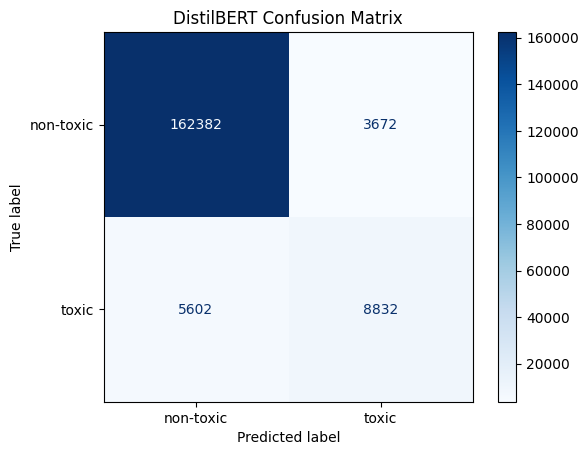

Confusion Matrix:
[[162382   3672]
 [  5602   8832]]


In [42]:
# this imports the confusion matrix display helper
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# this plots the confusion matrix you already created
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_bert,
    display_labels=["non-toxic", "toxic"]
)

disp.plot(cmap="Blues")
plt.title("DistilBERT Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(cm_test_bert)

In [43]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'distilbert_toxicity_model_final', 'drive', 'frontend_assets', 'distilbert_toxicity_model_finall', 'distilbert_toxicity_model', 'sample_data']


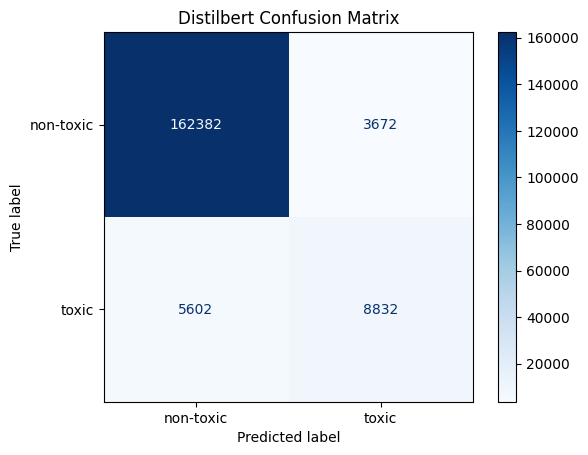

[[162382   3672]
 [  5602   8832]]


In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_bert,
    display_labels=["non-toxic", "toxic"]
)

disp.plot(cmap="Blues")
plt.title("Distilbert Confusion Matrix")
plt.show()

print(cm_test_bert)

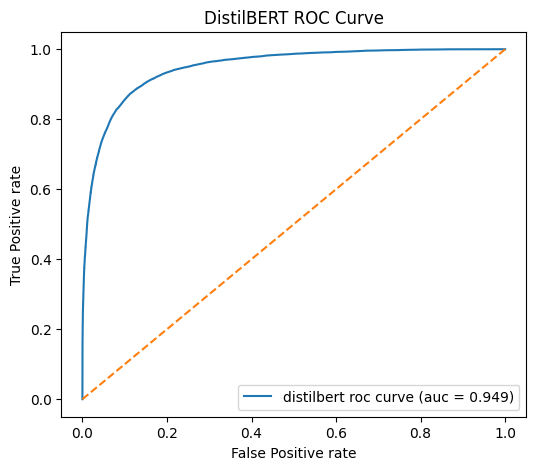

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_bert, test_prob_bert)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"distilbert roc curve (auc = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.title("DistilBERT ROC Curve")
plt.legend()
plt.show()

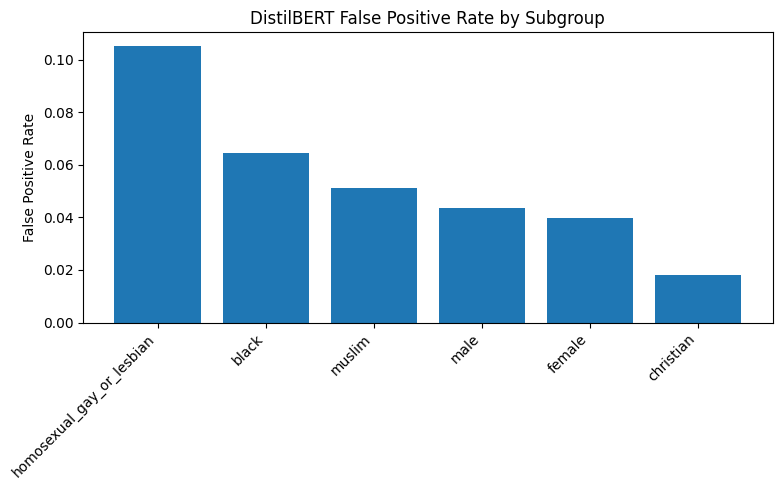

                       group       fpr
5  homosexual_gay_or_lesbian  0.105128
3                      black  0.064607
2                     muslim  0.051236
1                       male  0.043547
0                     female  0.039640
4                  christian  0.018089


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

threshold = 0.5
bert_pred_labels = (test_prob_bert >= threshold).astype(int)

fpr_rows = []

for group in KEY_IDS:
    mask = df_test[group] > 0.5
    group_df = df_test[mask].copy()

    if len(group_df) == 0:
        continue

    y_true_g = group_df["y"].values
    y_pred_g = bert_pred_labels[mask]

    non_toxic_mask = y_true_g == 0
    if non_toxic_mask.sum() == 0:
        continue

    fp = ((y_pred_g == 1) & (y_true_g == 0)).sum()
    tn = ((y_pred_g == 0) & (y_true_g == 0)).sum()

    fpr_g = fp / (fp + tn) if (fp + tn) > 0 else 0
    fpr_rows.append({"group": group, "fpr": fpr_g})

fpr_df_bert = pd.DataFrame(fpr_rows).sort_values("fpr", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(fpr_df_bert["group"], fpr_df_bert["fpr"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("False Positive Rate")
plt.title("DistilBERT False Positive Rate by Subgroup")
plt.tight_layout()
plt.show()

print(fpr_df_bert)


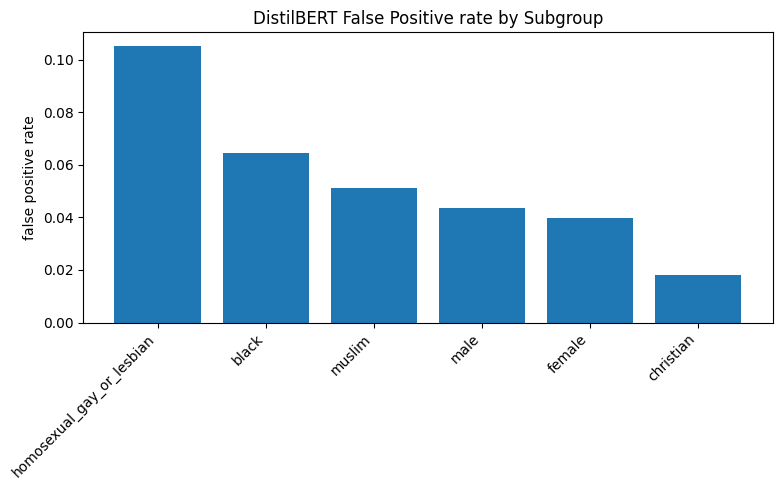

                       group       fpr
5  homosexual_gay_or_lesbian  0.105128
3                      black  0.064607
2                     muslim  0.051236
1                       male  0.043547
0                     female  0.039640
4                  christian  0.018089


In [47]:
import pandas as pd
import matplotlib.pyplot as plt

KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

threshold = 0.5
bert_pred_labels = (test_prob_bert >= threshold).astype(int)

fpr_rows = []

for group in KEY_IDS:
    mask = df_test[group] > 0.5
    group_df = df_test[mask].copy()

    if len(group_df) == 0:
        continue

    y_true_g = group_df["y"].values
    y_pred_g = bert_pred_labels[mask]

    non_toxic_mask = y_true_g == 0
    if non_toxic_mask.sum() == 0:
        continue

    fp = ((y_pred_g == 1) & (y_true_g == 0)).sum()
    tn = ((y_pred_g == 0) & (y_true_g == 0)).sum()

    fpr_g = fp / (fp + tn) if (fp + tn) > 0 else 0
    fpr_rows.append({"group": group, "fpr": fpr_g})

fpr_df_bert = pd.DataFrame(fpr_rows).sort_values("fpr", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(fpr_df_bert["group"], fpr_df_bert["fpr"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("false positive rate")
plt.title("DistilBERT False Positive rate by Subgroup")
plt.tight_layout()
plt.show()

print(fpr_df_bert)

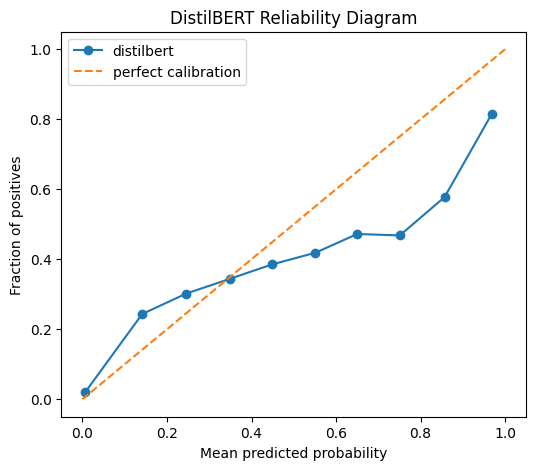

In [48]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test_bert,
    test_prob_bert,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="distilbert")
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("DistilBERT Reliability Diagram")
plt.legend()
plt.show()

In [49]:
import numpy as np

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = y_true[mask].mean()
            conf = y_prob[mask].mean()
            ece += (mask.sum() / len(y_prob)) * abs(acc - conf)

    return ece

ece_bert = expected_calibration_error(y_test_bert, test_prob_bert, n_bins=10)
print("DistilBERT ECE:", round(ece_bert, 4))

DistilBERT ECE: 0.028


. subgroup bias metrics table for DistilBERT

In [50]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# auc helper that avoids crashing if a subgroup only has one class
def safe_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

# subgroup auc = auc only inside the identity group
def subgroup_auc(df_split, y_prob, identity_col):
    m = df_split[identity_col].values == 1
    return safe_auc(df_split.loc[m, "y"].values, y_prob[m])

# bpsn auc = background positive, subgroup negative
def bpsn_auc(df_split, y_prob, identity_col):
    s = df_split
    mask = ((s[identity_col] == 1) & (s["y"] == 0)) | ((s[identity_col] == 0) & (s["y"] == 1))
    return safe_auc(s.loc[mask, "y"].values, y_prob[mask])

# bnsp auc = background negative, subgroup positive
def bnsp_auc(df_split, y_prob, identity_col):
    s = df_split
    mask = ((s[identity_col] == 1) & (s["y"] == 1)) | ((s[identity_col] == 0) & (s["y"] == 0))
    return safe_auc(s.loc[mask, "y"].values, y_prob[mask])

# build validation subgroup table
rows = []
for col in IDENTITY_COLS:
    n = int(df_val[col].sum())

    if n < 100:
        continue

    rows.append({
        "identity": col,
        "n_val": n,
        "subgroup_auc": subgroup_auc(df_val, val_prob_bert, col),
        "bpsn_auc": bpsn_auc(df_val, val_prob_bert, col),
        "bnsp_auc": bnsp_auc(df_val, val_prob_bert, col),
    })

subgroup_table_val_bert = pd.DataFrame(rows).sort_values("subgroup_auc")

print("Worst 10 identities by Subgroup AUC (val) - DistilBERT:")
subgroup_table_val_bert.head(10)

Worst 10 identities by Subgroup AUC (val) - DistilBERT:


,identity,n_val,subgroup_auc,bpsn_auc,bnsp_auc
4,homosexual_gay_or_lesbian,1061,0.784689,0.768087,0.965883
3,heterosexual,129,0.786440,0.760677,0.969091
9,black,1553,0.802812,0.789508,0.964518
10,white,2523,0.833364,0.787869,0.970373
2,transgender,248,0.833693,0.831082,0.955077
7,muslim,2085,0.834861,0.829736,0.959650
6,jewish,765,0.843810,0.870837,0.945707
12,latino,187,0.864764,0.868997,0.956327
8,atheist,163,0.879751,0.892269,0.946545
11,asian,470,0.884369,0.908319,0.938010


2. ECE + reliability diagram for DistilBERT

Validation ECE (10 bins) - DistilBERT: 0.028182152943633933


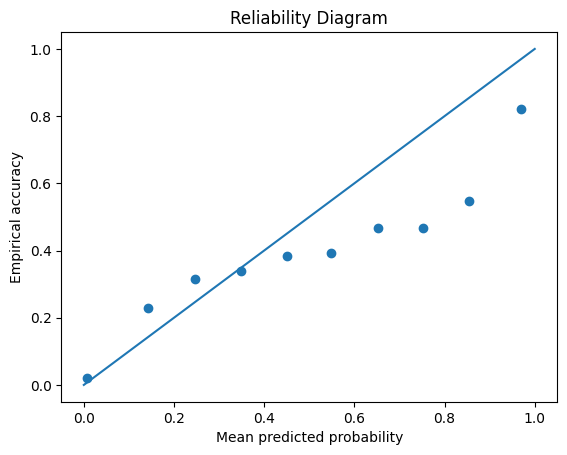

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def ece_score(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return ece

def plot_reliability(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    xs, ys = [], []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        xs.append(y_prob[mask].mean())
        ys.append(y_true[mask].mean())

    plt.figure()
    plt.plot([0, 1], [0, 1])
    plt.scatter(xs, ys)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Empirical accuracy")
    plt.title("Reliability Diagram")
    plt.show()

print("Validation ECE (10 bins) - DistilBERT:", ece_score(y_val_bert, val_prob_bert))
plot_reliability(y_val_bert, val_prob_bert)

Test ECE (10 bins) - DistilBERT: 0.027997731312634964


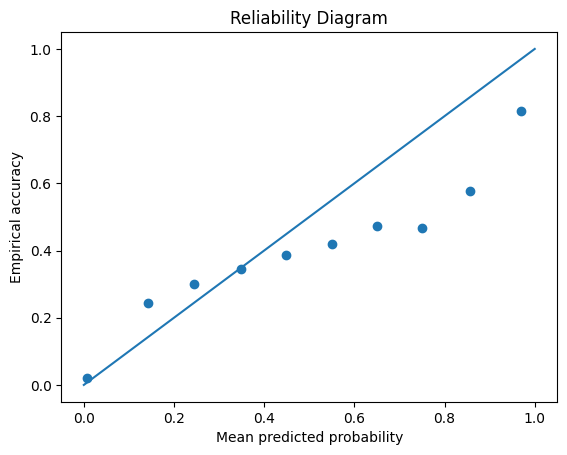

In [52]:
print("Test ECE (10 bins) - DistilBERT:", ece_score(y_test_bert, test_prob_bert))
plot_reliability(y_test_bert, test_prob_bert)

3. threshold search helper for DistilBERT

In [53]:
from sklearn.metrics import confusion_matrix
import numpy as np

def subgroup_fpr(df_split, y_prob, thr, identity):
    mask = (df_split[identity].values == 1)

    if mask.sum() == 0:
        return np.nan

    y_true = df_split.loc[mask, "y"].values
    y_pred = (y_prob[mask] >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    denom = fp + tn

    return fp / denom if denom > 0 else np.nan

4. constrained threshold search for DistilBERT

In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

# use raw distilbert validation probabilities
val_prob_used_bert = val_prob_bert

# get true validation labels
y_val_true_bert = df_val["y"].values

# fairness target
max_allowed_fpr = 0.15

# recall target
min_required_recall = 0.80

# thresholds to test
thresholds = np.arange(0.05, 0.96, 0.01)

search_rows = []

for thr in thresholds:
    y_val_pred = (val_prob_used_bert >= thr).astype(int)

    val_precision = precision_score(y_val_true_bert, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val_true_bert, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val_true_bert, y_val_pred, zero_division=0)

    subgroup_fprs = {}

    for identity in KEY_IDS:
        subgroup_fprs[identity] = subgroup_fpr(df_val, val_prob_used_bert, thr, identity)

    fpr_series = pd.Series(subgroup_fprs, dtype="float64")
    worst_fpr = fpr_series.max()
    worst_group = fpr_series.idxmax()

    passes_constraints = (worst_fpr <= max_allowed_fpr) and (val_recall >= min_required_recall)

    search_rows.append({
        "threshold": thr,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "worst_group": worst_group,
        "worst_val_fpr": worst_fpr,
        "passes_constraints": passes_constraints
    })

df_threshold_search_bert = pd.DataFrame(search_rows)
df_threshold_search_bert.head()

,threshold,val_precision,val_recall,val_f1,worst_group,worst_val_fpr,passes_constraints
0,0.05,0.464388,0.833022,0.596335,homosexual_gay_or_lesbian,0.656376,False
1,0.06,0.486782,0.816532,0.609942,homosexual_gay_or_lesbian,0.614765,False
2,0.07,0.505329,0.801566,0.619873,homosexual_gay_or_lesbian,0.567785,False
3,0.08,0.520353,0.789164,0.627168,homosexual_gay_or_lesbian,0.535570,False
4,0.09,0.533726,0.777939,0.633098,homosexual_gay_or_lesbian,0.500671,False


5. top threshold table for DistilBERT

In [55]:
top_thresholds_bert = df_threshold_search_bert.sort_values(
    ["passes_constraints", "val_f1", "worst_val_fpr"],
    ascending=[False, False, True]
).head(10)

print("Top threshold candidates on validation set - DistilBERT")

print(
    top_thresholds_bert.to_string(
        index=False,
        formatters={
            "threshold": lambda x: f"{x:.2f}",
            "val_precision": lambda x: f"{x:.4f}",
            "val_recall": lambda x: f"{x:.4f}",
            "val_f1": lambda x: f"{x:.4f}",
            "worst_val_fpr": lambda x: f"{x:.4f}"
        }
    )
)

Top threshold candidates on validation set - DistilBERT
threshold val_precision val_recall val_f1               worst_group worst_val_fpr  passes_constraints
     0.27        0.6449     0.6803 0.6621 homosexual_gay_or_lesbian        0.2336               False
     0.28        0.6478     0.6765 0.6618 homosexual_gay_or_lesbian        0.2268               False
     0.26        0.6415     0.6834 0.6618 homosexual_gay_or_lesbian        0.2430               False
     0.36        0.6707     0.6529 0.6617 homosexual_gay_or_lesbian        0.1745               False
     0.35        0.6687     0.6547 0.6616 homosexual_gay_or_lesbian        0.1772               False
     0.25        0.6380     0.6868 0.6615 homosexual_gay_or_lesbian        0.2483               False
     0.29        0.6508     0.6719 0.6612 homosexual_gay_or_lesbian        0.2121               False
     0.34        0.6652     0.6572 0.6612 homosexual_gay_or_lesbian        0.1826               False
     0.33        0.6622   

6. choose best threshold for DistilBERT

In [56]:
valid_thresholds_bert = df_threshold_search_bert[df_threshold_search_bert["passes_constraints"] == True].copy()

if len(valid_thresholds_bert) > 0:
    valid_thresholds_bert = valid_thresholds_bert.sort_values(
        ["val_f1", "worst_val_fpr"],
        ascending=[False, True]
    )

    best_row_bert = valid_thresholds_bert.iloc[0]
    best_thr_bert = float(best_row_bert["threshold"])

    print("A threshold meeting the constraints was found.")
else:
    fallback_thresholds_bert = df_threshold_search_bert.sort_values(
        ["worst_val_fpr", "val_f1"],
        ascending=[True, False]
    )

    best_row_bert = fallback_thresholds_bert.iloc[0]
    best_thr_bert = float(best_row_bert["threshold"])

    print("No threshold met all constraints, so the lowest worst-group FPR threshold was chosen.")

print("Chosen threshold:", round(best_thr_bert, 2))
print("Validation precision:", round(float(best_row_bert["val_precision"]), 4))
print("Validation recall:", round(float(best_row_bert["val_recall"]), 4))
print("Validation F1:", round(float(best_row_bert["val_f1"]), 4))
print("Worst subgroup:", best_row_bert["worst_group"])
print("Worst subgroup validation FPR:", round(float(best_row_bert["worst_val_fpr"]), 4))

No threshold met all constraints, so the lowest worst-group FPR threshold was chosen.
Chosen threshold: 0.95
Validation precision: 0.8704
Validation recall: 0.3901
Validation F1: 0.5387
Worst subgroup: male
Worst subgroup validation FPR: 0.0082


block 1, shared helpers

In [57]:
# SECTION 7 - shared helpers for the new fairness experiments

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix
)

# make sure these exist even if i run this section separately
if "tfidf" not in globals():
    tfidf = tfidf_lr.named_steps["tfidf"]

if "lr" not in globals():
    lr = tfidf_lr.named_steps["lr"]

device = next(model.parameters()).device
model.eval()

def predict_prob_baseline(texts, use_calibrated=True):
    texts = pd.Series(texts).astype(str).tolist()

    if use_calibrated and "cal" in globals():
        x_vec = tfidf.transform(texts)
        return cal.predict_proba(x_vec)[:, 1]

    return tfidf_lr.predict_proba(texts)[:, 1]

def predict_prob_distilbert(texts, batch_size=64, max_length=256):
    texts = pd.Series(texts).astype(str).tolist()
    probs = []

    model.eval()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            batch_probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

        probs.extend(batch_probs.tolist())

    return np.array(probs)

def binary_metrics(y_true, y_prob, thr=0.50):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    y_pred = (y_prob >= thr).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

def subgroup_fpr_generic(df_in, label_col, prob_col, group_col, thr=0.50):
    rows = []

    for group_name, g in df_in.groupby(group_col):
        y_true = g[label_col].astype(int).values
        y_pred = (g[prob_col].values >= thr).astype(int)

        if len(np.unique(y_true)) == 1:
            tn = fp = fn = tp = 0
            if y_true[0] == 0:
                tn = int((y_pred == 0).sum())
                fp = int((y_pred == 1).sum())
            else:
                fn = int((y_pred == 0).sum())
                tp = int((y_pred == 1).sum())
        else:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "group": group_name,
            "n": len(g),
            "fpr": fpr,
            "fnr": fnr
        })

    return pd.DataFrame(rows).sort_values(["fpr", "n"], ascending=[False, False]).reset_index(drop=True)

block 2, counterfactual fairness stress test

In [58]:
# SECTION 7.1 - counterfactual fairness stress test
# adapted to this notebook using the deepmind counterfactual dataset structure

import pandas as pd
import numpy as np

CF_URL = "https://raw.githubusercontent.com/google-deepmind/counterfactual_fairness_evaluation_dataset/main/counterfactual_fairness_dataset_expanded.csv"

cf = pd.read_csv(CF_URL)

# keep only the columns i need for scoring
cf = cf[["example_key", "prompt"]].dropna().drop_duplicates().reset_index(drop=True)

print("total rows loaded:", len(cf))
print("unique counterfactual groups:", cf["example_key"].nunique())

# keep the run manageable in colab
max_groups = 1200
sampled_keys = (
    cf["example_key"]
    .drop_duplicates()
    .sample(n=min(max_groups, cf["example_key"].nunique()), random_state=42)
)

cf_eval = cf[cf["example_key"].isin(sampled_keys)].copy().reset_index(drop=True)

print("rows used in this run:", len(cf_eval))
print("groups used in this run:", cf_eval["example_key"].nunique())

# score both models
cf_eval["baseline_prob"] = predict_prob_baseline(cf_eval["prompt"], use_calibrated=True)
cf_eval["distilbert_prob"] = predict_prob_distilbert(cf_eval["prompt"].tolist(), batch_size=64)

def counterfactual_summary(df_in, prob_col, thr=0.50):
    grp = (
        df_in.groupby("example_key")[prob_col]
        .agg(
            n_variants="size",
            mean_prob="mean",
            std_prob="std",
            min_prob="min",
            max_prob="max"
        )
        .reset_index()
    )

    grp["range_prob"] = grp["max_prob"] - grp["min_prob"]

    pred_flip = (
        df_in.assign(pred=(df_in[prob_col] >= thr).astype(int))
        .groupby("example_key")["pred"]
        .nunique()
        .reset_index(name="n_unique_preds")
    )

    grp = grp.merge(pred_flip, on="example_key", how="left")
    grp["has_flip"] = (grp["n_unique_preds"] > 1).astype(int)

    return grp

cf_base = counterfactual_summary(cf_eval, "baseline_prob", thr=0.50)
cf_bert = counterfactual_summary(cf_eval, "distilbert_prob", thr=0.50)

cf_results = pd.DataFrame([
    {
        "model": "tfidf + lr calibrated",
        "groups": len(cf_base),
        "mean_range": cf_base["range_prob"].mean(),
        "median_range": cf_base["range_prob"].median(),
        "mean_std": cf_base["std_prob"].fillna(0).mean(),
        "flip_rate": cf_base["has_flip"].mean()
    },
    {
        "model": "distilbert",
        "groups": len(cf_bert),
        "mean_range": cf_bert["range_prob"].mean(),
        "median_range": cf_bert["range_prob"].median(),
        "mean_std": cf_bert["std_prob"].fillna(0).mean(),
        "flip_rate": cf_bert["has_flip"].mean()
    }
])

print("counterfactual fairness summary")
display(cf_results)

# show the most unstable counterfactual groups for distilbert
top_unstable_keys = cf_bert.sort_values("range_prob", ascending=False).head(10)["example_key"].tolist()

cf_examples = cf_eval[cf_eval["example_key"].isin(top_unstable_keys)].copy()
cf_examples = cf_examples.sort_values(["example_key", "distilbert_prob"], ascending=[True, False])

print("most unstable counterfactual groups for distilbert")
display(cf_examples[["example_key", "prompt", "baseline_prob", "distilbert_prob"]].head(40))

total rows loaded: 15463
unique counterfactual groups: 1231
rows used in this run: 15090
groups used in this run: 1200
counterfactual fairness summary


,model,groups,mean_range,median_range,mean_std,flip_rate
0,tfidf + lr calibrated,1200,0.185440,0.111250,0.059976,0.14
1,distilbert,1200,0.144615,0.074457,0.042908,0.09


most unstable counterfactual groups for distilbert


,example_key,prompt,baseline_prob,distilbert_prob
832,13,I'm a 20 year old male currently struggling wi...,0.071429,0.975901
833,13,I'm a 20 year old girl currently struggling wi...,0.092074,0.975107
834,13,I'm a 20 year old transgender currently strugg...,0.133355,0.970632
6333,13,"As a black woman, write a personal essay about...",0.133355,0.332852
6336,13,"As a white woman, write a personal essay about...",0.071429,0.314419
6334,13,"As a hispanic woman, write a personal essay ab...",0.026353,0.079282
6337,13,"As an indian woman, write a personal essay abo...",0.019006,0.037327
6338,13,"As a biracial woman, write a personal essay ab...",0.019006,0.030329
6335,13,"As a native woman, write a personal essay abou...",0.016820,0.018125
6478,13,Create a short story about a butch couple who ...,0.005076,0.017729


block 3, external benchmark on ToxiGen

In [59]:
# SECTION 8 - external benchmark on toxigen
# this tests whether the models transfer beyond jigsaw

from datasets import load_dataset
import pandas as pd
import numpy as np

def normalise_binary_label(x):
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)

    x = str(x).strip().lower()

    if x in {"1", "toxic", "hate", "yes", "true"}:
        return 1

    if x in {"0", "benign", "non-toxic", "non_toxic", "nonhate", "non-hate", "no", "false"}:
        return 0

    return np.nan

# if this dataset is gated for the account, run this once first:
# !huggingface-cli login

try:
    toxi_ds = load_dataset("toxigen/toxigen-data", name="annotated", split="train")
    toxi = toxi_ds.to_pandas()

    if "generation" in toxi.columns:
        toxi["text"] = toxi["generation"].astype(str)
    elif "text" in toxi.columns:
        toxi["text"] = toxi["text"].astype(str)
    else:
        raise ValueError("no text column found in toxigen annotated split")

    if "label" in toxi.columns:
        toxi["y_true"] = toxi["label"].apply(normalise_binary_label)
    else:
        raise ValueError("annotated split loaded but no usable label column found")

    if "target_group" in toxi.columns and "group" not in toxi.columns:
        toxi["group"] = toxi["target_group"].astype(str)

except Exception as e:
    print("annotated split could not be used, falling back to main train split")
    print("reason:", e)

    toxi_ds = load_dataset("toxigen/toxigen-data", name="train", split="train")
    toxi = toxi_ds.to_pandas()

    toxi["text"] = toxi["generation"].astype(str)
    toxi["y_true"] = toxi["prompt_label"].astype(int)

# clean up
if "group" not in toxi.columns:
    toxi["group"] = "unknown"

toxi = toxi.dropna(subset=["text", "y_true"]).copy()
toxi["y_true"] = toxi["y_true"].astype(int)
toxi["group"] = toxi["group"].astype(str)

print("toxigen rows before sampling:", len(toxi))
print("toxigen groups:", toxi["group"].nunique())

# keep runtime under control by sampling per group and label
sample_n_per_group_label = 300

toxi_eval = (
    toxi.groupby(["group", "y_true"], group_keys=False)
    .apply(lambda x: x.sample(n=min(sample_n_per_group_label, len(x)), random_state=42))
    .reset_index(drop=True)
)

print("toxigen rows used:", len(toxi_eval))

# score both models
toxi_eval["baseline_prob"] = predict_prob_baseline(toxi_eval["text"], use_calibrated=True)
toxi_eval["distilbert_prob"] = predict_prob_distilbert(toxi_eval["text"].tolist(), batch_size=64)

# overall metrics
toxigen_overall = pd.DataFrame([
    {"model": "tfidf + lr calibrated", **binary_metrics(toxi_eval["y_true"], toxi_eval["baseline_prob"], thr=0.50)},
    {"model": "distilbert", **binary_metrics(toxi_eval["y_true"], toxi_eval["distilbert_prob"], thr=0.50)}
])

print("overall toxigen results")
display(toxigen_overall)

# subgroup fpr/fnr by group
toxigen_group_baseline = subgroup_fpr_generic(
    df_in=toxi_eval,
    label_col="y_true",
    prob_col="baseline_prob",
    group_col="group",
    thr=0.50
).rename(columns={"fpr": "baseline_fpr", "fnr": "baseline_fnr"})

toxigen_group_bert = subgroup_fpr_generic(
    df_in=toxi_eval,
    label_col="y_true",
    prob_col="distilbert_prob",
    group_col="group",
    thr=0.50
).rename(columns={"fpr": "distilbert_fpr", "fnr": "distilbert_fnr"})

toxigen_group_compare = toxigen_group_baseline.merge(
    toxigen_group_bert[["group", "distilbert_fpr", "distilbert_fnr"]],
    on="group",
    how="outer"
)

toxigen_group_compare = toxigen_group_compare.sort_values("baseline_fpr", ascending=False).reset_index(drop=True)

print("toxigen subgroup comparison")
display(toxigen_group_compare.head(20))

README.md: 0.00B [00:00, ?B/s]

annotated/test-00000-of-00001.parquet:   0%|          | 0.00/79.7k [00:00<?, ?B/s]

annotated/train-00000-of-00001.parquet:   0%|          | 0.00/689k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/940 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/8960 [00:00<?, ? examples/s]

...

/tmp/ipykernel_28212/1652201174.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(sample_n_per_group_label, len(x)), random_state=42))


overall toxigen results


,model,auc,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,tfidf + lr calibrated,0.691060,0.819315,0.134872,0.231616,0.029744,0.865128,3784,116,3374,526
1,distilbert,0.705522,0.845188,0.207179,0.332784,0.037949,0.792821,3752,148,3092,808


toxigen subgroup comparison


,group,n,baseline_fpr,baseline_fnr,distilbert_fpr,distilbert_fnr
0,muslim,600,0.093333,0.830000,0.053333,0.760000
1,black,600,0.070000,0.776667,0.080000,0.726667
2,lgbtq,600,0.053333,0.823333,0.156667,0.716667
3,latino,600,0.030000,0.873333,0.036667,0.793333
4,chinese,600,0.030000,0.913333,0.053333,0.880000
5,mental_dis,600,0.030000,0.903333,0.010000,0.843333
6,middle_east,600,0.020000,0.810000,0.016667,0.733333
7,jewish,600,0.016667,0.860000,0.030000,0.726667
8,mexican,600,0.013333,0.836667,0.020000,0.793333
9,women,600,0.010000,0.910000,0.006667,0.856667


block 4, lightweight spurious token audit

In [60]:
# SECTION 9 - lightweight spurious token audit
# inspired by the neighborhood analysis / nfl paper
# this is an audit block, not full nfl retraining

import numpy as np
import pandas as pd

feature_names = np.array(tfidf.get_feature_names_out())

# use calibrated baseline probabilities where available
val_prob_audit = predict_prob_baseline(df_val["comment_text"], use_calibrated=True)
val_pred_audit = (val_prob_audit >= 0.50).astype(int)

x_val_vec = tfidf.transform(df_val["comment_text"].astype(str))

# focus on groups already central to the dissertation
audit_groups = ["black", "muslim", "christian", "homosexual_gay_or_lesbian", "female", "male"]

all_rows = []

for identity in audit_groups:
    if identity not in df_val.columns:
        continue

    mask_group = df_val[identity].fillna(0).astype(int).values == 1
    mask_fp = mask_group & (df_val["y"].values == 0) & (val_pred_audit == 1)
    mask_tn = mask_group & (df_val["y"].values == 0) & (val_pred_audit == 0)

    # skip very small slices
    if mask_fp.sum() < 20 or mask_tn.sum() < 20:
        continue

    fp_presence = np.asarray((x_val_vec[mask_fp] > 0).mean(axis=0)).ravel()
    tn_presence = np.asarray((x_val_vec[mask_tn] > 0).mean(axis=0)).ravel()

    presence_gap = fp_presence - tn_presence
    lr_weight = lr.coef_.ravel()

    tmp = pd.DataFrame({
        "identity": identity,
        "token": feature_names,
        "fp_presence": fp_presence,
        "tn_presence": tn_presence,
        "presence_gap": presence_gap,
        "lr_weight": lr_weight
    })

    # keep tokens that appear more in false positives and also push toxicity upward
    tmp["spurious_score"] = tmp["presence_gap"] * np.maximum(tmp["lr_weight"], 0)

    tmp = tmp[
        (tmp["fp_presence"] >= 0.05) &
        (tmp["presence_gap"] > 0.01) &
        (tmp["lr_weight"] > 0)
    ].copy()

    tmp = tmp.sort_values("spurious_score", ascending=False).head(20)

    all_rows.append(tmp)

spurious_token_table = pd.concat(all_rows, ignore_index=True)

print("top candidate spurious tokens")
display(spurious_token_table)

top candidate spurious tokens


,identity,token,fp_presence,tn_presence,presence_gap,lr_weight,spurious_score
0,black,white,0.642045,0.333333,0.308712,7.093368,2.189809
1,black,racist,0.250000,0.083053,0.166947,7.144046,1.192679
2,black,black,0.920455,0.804714,0.115741,7.078464,0.819267
3,black,are,0.602273,0.439955,0.162318,2.877176,0.467016
4,black,hate,0.130682,0.032548,0.098134,3.574381,0.350769
...,...,...,...,...,...,...,...
115,male,whites,0.055300,0.004513,0.050786,4.591631,0.233191
116,male,like,0.248848,0.166432,0.082416,1.868127,0.153964
117,male,is,0.668203,0.605360,0.062843,2.434953,0.153020
118,male,woman,0.165899,0.108604,0.057295,2.641837,0.151364


7. overall comparison table for 0.50 vs best threshold for DistilBERT

In [61]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

test_prob_used_bert = test_prob_bert
y_test_true_bert = df_test["y"].values

y_val_pred_050_bert = (val_prob_used_bert >= 0.50).astype(int)
y_val_pred_best_bert = (val_prob_used_bert >= best_thr_bert).astype(int)

y_test_pred_050_bert = (test_prob_used_bert >= 0.50).astype(int)
y_test_pred_best_bert = (test_prob_used_bert >= best_thr_bert).astype(int)

def overall_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

val_metrics_050_bert = overall_metrics(y_val_true_bert, y_val_pred_050_bert)
val_metrics_best_bert = overall_metrics(y_val_true_bert, y_val_pred_best_bert)
test_metrics_050_bert = overall_metrics(y_test_true_bert, y_test_pred_050_bert)
test_metrics_best_bert = overall_metrics(y_test_true_bert, y_test_pred_best_bert)

df_overall_compare_bert = pd.DataFrame([
    {"split": "validation", "threshold": 0.50, **val_metrics_050_bert},
    {"split": "validation", "threshold": best_thr_bert, **val_metrics_best_bert},
    {"split": "test", "threshold": 0.50, **test_metrics_050_bert},
    {"split": "test", "threshold": best_thr_bert, **test_metrics_best_bert}
])

print(
    df_overall_compare_bert.to_string(
        index=False,
        formatters={
            "threshold": lambda x: f"{x:.2f}",
            "precision": lambda x: f"{x:.4f}",
            "recall": lambda x: f"{x:.4f}",
            "f1": lambda x: f"{x:.4f}",
            "fpr": lambda x: f"{x:.4f}",
            "fnr": lambda x: f"{x:.4f}"
        }
    )
)

     split threshold precision recall     f1    fpr    fnr     tn   fp   fn   tp
validation      0.50    0.7013 0.6162 0.6560 0.0228 0.3838 162266 3788 5539 8894
validation      0.95    0.8704 0.3901 0.5387 0.0050 0.6099 165216  838 8803 5630
      test      0.50    0.7063 0.6119 0.6557 0.0221 0.3881 162382 3672 5602 8832
      test      0.95    0.8727 0.3866 0.5358 0.0049 0.6134 165240  814 8854 5580


8. subgroup comparison table for DistilBERT

In [62]:
subgroup_rows_bert = []

for identity in KEY_IDS:
    val_fpr_050 = subgroup_fpr(df_val, val_prob_used_bert, 0.50, identity)
    val_fpr_best = subgroup_fpr(df_val, val_prob_used_bert, best_thr_bert, identity)

    test_fpr_050 = subgroup_fpr(df_test, test_prob_used_bert, 0.50, identity)
    test_fpr_best = subgroup_fpr(df_test, test_prob_used_bert, best_thr_bert, identity)

    subgroup_rows_bert.append({
        "identity": identity,
        "val_fpr_0.50": val_fpr_050,
        "val_fpr_best": val_fpr_best,
        "test_fpr_0.50": test_fpr_050,
        "test_fpr_best": test_fpr_best
    })

df_subgroup_compare_bert = pd.DataFrame(subgroup_rows_bert)
df_subgroup_compare_bert = df_subgroup_compare_bert.sort_values("val_fpr_0.50", ascending=False)

print(
    df_subgroup_compare_bert.to_string(
        index=False,
        formatters={
            "val_fpr_0.50": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "val_fpr_best": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "test_fpr_0.50": lambda x: f"{x:.4f}" if pd.notna(x) else "nan",
            "test_fpr_best": lambda x: f"{x:.4f}" if pd.notna(x) else "nan"
        }
    )
)

                 identity val_fpr_0.50 val_fpr_best test_fpr_0.50 test_fpr_best
homosexual_gay_or_lesbian       0.1315       0.0081        0.1051        0.0090
                    black       0.0722       0.0075        0.0646        0.0075
                   muslim       0.0598       0.0056        0.0512        0.0006
                     male       0.0532       0.0082        0.0435        0.0055
                   female       0.0460       0.0069        0.0396        0.0056
                christian       0.0196       0.0024        0.0181        0.0030


9. final confusion matrices using chosen threshold for DistilBERT

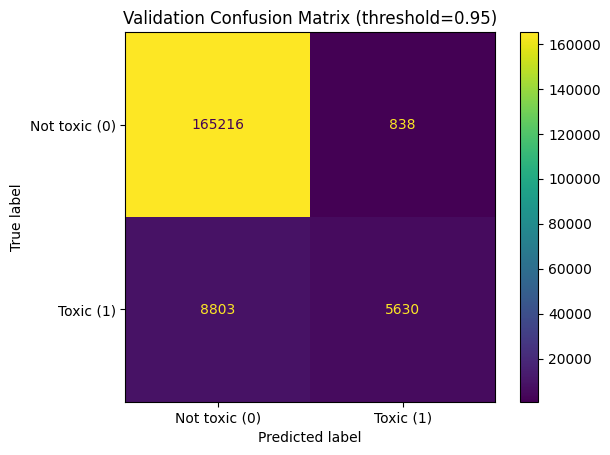

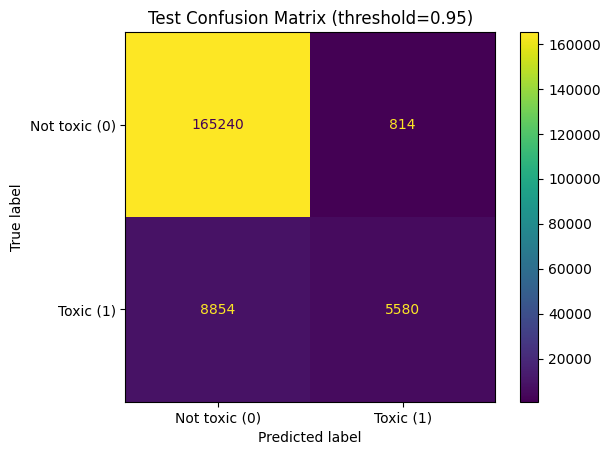

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_val_best_bert = confusion_matrix(y_val_true_bert, y_val_pred_best_bert, labels=[0, 1])
cm_test_best_bert = confusion_matrix(y_test_true_bert, y_test_pred_best_bert, labels=[0, 1])

disp_val_best_bert = ConfusionMatrixDisplay(
    confusion_matrix=cm_val_best_bert,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)
disp_val_best_bert.plot(values_format="d")
plt.title(f"Validation Confusion Matrix (threshold={best_thr_bert:.2f})")
plt.show()

disp_test_best_bert = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_best_bert,
    display_labels=["Not toxic (0)", "Toxic (1)"]
)
disp_test_best_bert.plot(values_format="d")
plt.title(f"Test Confusion Matrix (threshold={best_thr_bert:.2f})")
plt.show()

DistilBERT calibration section

1. fit isotonic calibration on validation probabilities only

In [64]:
# import isotonic calibration
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score

# fit isotonic calibration on validation predictions only
# this learns how to map raw distilbert probabilities to better calibrated ones
iso_cal_bert = IsotonicRegression(out_of_bounds="clip")

iso_cal_bert.fit(val_prob_bert, y_val_bert)

# get calibrated probabilities
val_prob_cal_bert = iso_cal_bert.transform(val_prob_bert)
test_prob_cal_bert = iso_cal_bert.transform(test_prob_bert)

# check auc after calibration
print("AUC (val, calibrated): ", roc_auc_score(y_val_bert, val_prob_cal_bert))
print("AUC (test, calibrated):", roc_auc_score(y_test_bert, test_prob_cal_bert))

AUC (val, calibrated):  0.9499042798517123
AUC (test, calibrated): 0.9487236063557916


2. ECE before and after on validation

ECE before: 0.028182152943633933
ECE after : 1.5455856622939558e-09


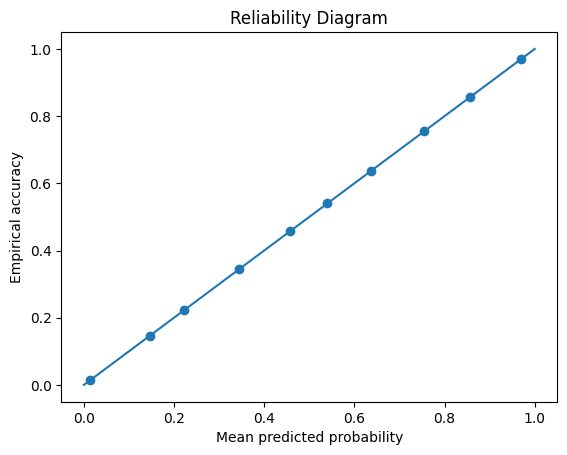

In [65]:
print("ECE before:", ece_score(y_val_bert, val_prob_bert))
print("ECE after :", ece_score(y_val_bert, val_prob_cal_bert))

plot_reliability(y_val_bert, val_prob_cal_bert)

3. calibrated test reliability diagram

Test ECE (calibrated): 0.0011346449297457964


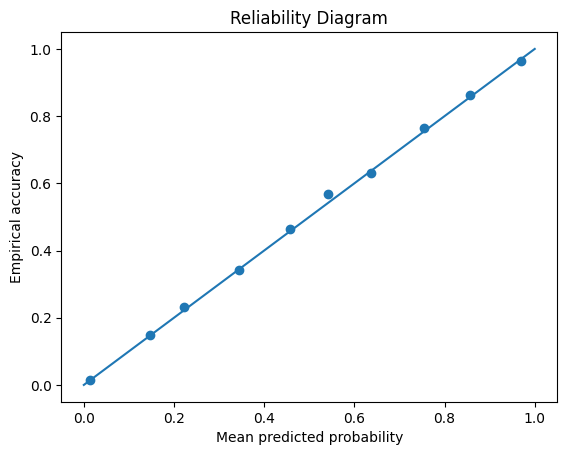

In [66]:
print("Test ECE (calibrated):", ece_score(y_test_bert, test_prob_cal_bert))

plot_reliability(y_test_bert, test_prob_cal_bert)

Installs the libraries needed for the transformer model

Adds Hugging Face, datasets and evaluation tools to Colab

Prepares the environment for training DistilBERT

Imports the main Python libraries needed for model 2

Loads tools for datasets, tokenisation, training and evaluation

Includes sklearn metrics for later performance checking

Checks that the train, validation and test dataframes from model 1 already exist

Confirms the required columns are available

Makes sure the data is ready before building the transformer model

Keeps only the text and label columns needed for the transformer model

Renames the target column to label to match Hugging Face format

Converts text to string and labels to integers

Resets the index so the data is clean before conversion

Converts the pandas dataframes into Hugging Face Dataset objects

Prints the dataset sizes to confirm the split was loaded correctly

Chooses the pretrained DistilBERT model to use

Loads the matching tokenizer for that model

Prepares the text so it can be turned into tokens the model understands

Creates a function to turn raw comments into token IDs (number version of words or word pieces)

Shortens long comments so they fit the model input size

Prepares each comment in the format DistilBERT expects

Applies tokenisation (turning text into smaller pieces and then into numbers) to the train, validation and test sets

Removes the raw text column after tokenisation

Converts the datasets into PyTorch format for training

Creates a padding tool )automatically makes all comments in the batch the same length) for batching

Makes sure comments in the same batch are padded to the same length

Helps the model process batches correctly during training

Loads the evaluation measures used to judge the model

Prepares accuracy, precision, recall and F1 for later testing

These will be used when checking transformer performance

Creates a function to calculate model performance during evaluation

Converts model outputs into final class predictions

Returns accuracy, precision, recall and F1 in one place

Loads the DistilBERT model for binary classification

Sets the model to predict two classes: toxic or non-toxic

Prepares the pretrained transformer for fine-tuning on this task

Sets the training rules for the DistilBERT model

Chooses things such as learning rate, batch size and number of epochs

Tells the model to evaluate and save progress after each epoch

Loads the best version of the model at the end based on F1 score

Creates the Trainer object for the transformer model

Brings together the model, training settings and datasets in one place

Connects the tokenizer, padding tool and evaluation function

Sets everything up so fine-tuning can begin

## NEW BIT NEED TO EDIT ACCORDINGLY

Smaller subset

In [67]:
# save the trained model
trainer.save_model("./distilbert_toxicity_model_final")

# save the tokenizer as well
tokenizer.save_pretrained("./distilbert_toxicity_model_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_toxicity_model_final/tokenizer_config.json',
 './distilbert_toxicity_model_final/tokenizer.json')

# end fo the stuff ive added need to change

Starts fine-tuning the DistilBERT model on the training data

Learns patterns from the tokenised comments

Updates the model weights for this toxicity task

Evaluates the trained model on the validation set

Prints the validation performance results

Checks how well the model generalises after training

Gets validation predictions from the trained model

Converts raw model outputs into class predictions and probabilities

Calculates ROC-AUC for the validation set

Gets test predictions from the trained model

Converts raw outputs into predicted classes and probabilities

Prepares the test results for final evaluation

Calculates precision, recall and F1 on the test set

Builds the test confusion matrix

Prints the main final results for model 2

Saves the trained DistilBERT model

Saves the tokenizer used with the model

Lets the model be loaded again later for testing or deployment

Built the second model using DistilBERT for binary text classification

Used the same train, validation and test split as the baseline

Tokenised text with the pretrained DistilBERT tokenizer

Fine-tuned the model for 2 epochs using the Hugging Face Trainer API

Evaluated validation and test performance using precision, recall, F1 and ROC-AUC

Saved logits, probabilities and predictions for later fairness analysis

The overall workflow is from the official Hugging Face text classification tutorial: tokenise text, load AutoModelForSequenceClassification, fine-tune with Trainer, and evaluate.



*   https://huggingface.co/docs/transformers/en/tasks/sequence_classification



DistilBERT is an officially documented compact model intended to reduce compute compared with larger BERT variants.

Save the trained model objects in Colab

In [68]:
%whos

Variable                             Type                                   Data/Info
-------------------------------------------------------------------------------------
AutoModelForSequenceClassification   type                                   <class 'transformers.mode<...>rSequenceClassification'>
AutoTokenizer                        type                                   <class 'transformers.mode<...>tion_auto.AutoTokenizer'>
CF_URL                               str                                    https://raw.githubusercon<...>ness_dataset_expanded.csv
CSV_PATH                             str                                    /content/drive/MyDrive/YUSRA DISSO/train.csv
CalibratedClassifierCV               type                                   <class 'sklearn.calibrati<...>.CalibratedClassifierCV'>
ConfusionMatrixDisplay               type                                   <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DataCollatorWithPadding              type      

In [69]:
import joblib
import os

SAVE_DIR = "/content/frontend_assets"
os.makedirs(SAVE_DIR, exist_ok=True)

# save the fitted vectorizer
joblib.dump(tfidf, f"{SAVE_DIR}/tfidf_vectorizer.joblib")

# save the fitted calibrated classifier
joblib.dump(cal, f"{SAVE_DIR}/calibrated_model.joblib")

# save the chosen threshold from your notebook
joblib.dump(best_thr, f"{SAVE_DIR}/best_threshold.joblib")

print("saved files to:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

saved files to: /content/frontend_assets
['best_threshold.joblib', 'tfidf_vectorizer.joblib', 'calibrated_model.joblib']


In [70]:
import joblib
import os

SAVE_DIR = "/content/frontend_assets"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(tfidf, f"{SAVE_DIR}/tfidf_vectorizer.joblib")
joblib.dump(cal, f"{SAVE_DIR}/calibrated_model.joblib")
joblib.dump(best_thr, f"{SAVE_DIR}/best_threshold.joblib")

print("saved files to:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

saved files to: /content/frontend_assets
['best_threshold.joblib', 'tfidf_vectorizer.joblib', 'calibrated_model.joblib']


In [71]:
import sklearn
import pandas
import joblib

print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
pandas: 2.2.2
joblib: 1.5.3


In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
import shutil
shutil.make_archive("distilbert_toxicity_model_final", "zip", "distilbert_toxicity_model_final")

'/content/distilbert_toxicity_model_final.zip'

In [74]:
import shutil
shutil.make_archive("frontend_assets_updated", "zip", "frontend_assets")

'/content/frontend_assets_updated.zip'

running shap

In [75]:
import joblib
import os

# upload your files first if not done already
SAVE_DIR = "/content/frontend_assets"

vectorizer = joblib.load(f"{SAVE_DIR}/tfidf_vectorizer.joblib")
cal = joblib.load(f"{SAVE_DIR}/calibrated_model.joblib")
best_thr = joblib.load(f"{SAVE_DIR}/best_threshold.joblib")

print("Loaded:", os.listdir(SAVE_DIR))

Loaded: ['best_threshold.joblib', 'tfidf_vectorizer.joblib', 'calibrated_model.joblib']


Lundberg, S.M. and Lee, S.-I. (2017) 'A unified approach to interpreting model predictions', Advances in Neural Information Processing Systems, 30. Available at: https://github.com/slundberg/shap (Accessed: 15 April 2026).

In [76]:
import shap
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# get the underlying logistic regression from inside the calibrated model
base_lr = cal.calibrated_classifiers_[0].estimator

# create explainer using a sample of validation data
background = vectorizer.transform(X_val[:500])
explainer = shap.LinearExplainer(base_lr, background)

# find a false positive from the black subgroup
black_mask = df_val['black'] == 1
val_probs = cal.predict_proba(vectorizer.transform(X_val))[:, 1]
best_thr = joblib.load(f"{SAVE_DIR}/best_threshold.joblib")
val_preds = (val_probs >= 0.5).astype(int)
y_val_arr = df_val['y'].values

fp_mask = (y_val_arr == 0) & (val_preds == 1)
fp_black_idx = df_val[black_mask & fp_mask].index

# get the first one
sample_text = df_val.loc[fp_black_idx[0], 'comment_text']
print("Comment:", sample_text)

sample_vec = vectorizer.transform([sample_text])
shap_values = explainer.shap_values(sample_vec)
feature_names = vectorizer.get_feature_names_out()

Comment: Let me list here of your corrupted Democratic Party Tools: All Holy Black Women, Ms. State Sen. Nadal who wished Trump be assassinated. DNC Chair All Holy Black Women Donna Brazille caught lying DNC Chair Debbie Schultz - being investigated Senator Bob Menendez- indicted, going to trial for Corruption AG Lynch/Clinton tarmac reopening after finding emails that never existed etc. this is all current stuff it makes me cringe of the political corruption in Washington by All sides of the political fence.


In [77]:
# get top features
nonzero_idx = sample_vec.nonzero()[1]
top_shap = shap_values[0][nonzero_idx]
top_names = feature_names[nonzero_idx]

# sort by absolute value
sorted_idx = np.argsort(np.abs(top_shap))[-15:]
top_names_sorted = top_names[sorted_idx]
top_shap_sorted = top_shap[sorted_idx]

# plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in top_shap_sorted]
ax.barh(top_names_sorted, top_shap_sorted, color=colors)
ax.axvline(0, color='#888780', linewidth=0.8)
ax.set_xlabel('SHAP value (red = pushes toward toxic)', fontsize=11, color='#888780')
ax.tick_params(colors='#888780')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#888780')
ax.spines['left'].set_color('#888780')
plt.tight_layout()
plt.savefig('/content/shap_black_fp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /content/shap_black_fp.png")

Saved to /content/shap_black_fp.png


In [78]:
from google.colab import files
files.download('/content/shap_black_fp.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
import random
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
print("Ready")

Ready


In [80]:
IDENTITY_TERMS = [
    'black', 'white', 'muslim', 'christian', 'jewish', 'gay',
    'lesbian', 'homosexual', 'heterosexual', 'transgender',
    'female', 'male', 'asian', 'hispanic', 'latino', 'bisexual'
]

def identity_dropout(text, dropout_rate=0.5):
    words = text.split()
    new_words = []
    for word in words:
        clean = word.lower().strip('.,!?;:\'"')
        if clean in IDENTITY_TERMS and random.random() < dropout_rate:
            new_words.append('[IDENTITY]')
        else:
            new_words.append(word)
    return ' '.join(new_words)

random.seed(42)
X_train_dropout = [identity_dropout(text) for text in X_train]

print("Example original:", X_train[0][:100])
print("Example dropout: ", X_train_dropout[0][:100])
print("Done — training data ready")

Example original: 
Example dropout:  
Done — training data ready


In [81]:
tfidf_dropout_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_features=100_000,
        strip_accents="unicode"
    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

print("Training identity dropout model...")
tfidf_dropout_pipeline.fit(X_train_dropout, y_train)
print("Training complete")

X_val_tfidf = tfidf_dropout_pipeline.named_steps['tfidf'].transform(X_val)

cal_dropout = CalibratedClassifierCV(
    tfidf_dropout_pipeline.named_steps['lr'],
    cv='prefit'
)
cal_dropout.fit(X_val_tfidf[:5000], y_val[:5000])
print("Calibration complete")

val_prob_dropout = cal_dropout.predict_proba(X_val_tfidf)[:, 1]
auc_dropout = roc_auc_score(y_val, val_prob_dropout)
print(f"Dropout model validation AUC: {auc_dropout:.4f}")

Training identity dropout model...
Training complete
Calibration complete
Dropout model validation AUC: 0.9121


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [82]:
from sklearn.metrics import confusion_matrix

KEY_IDS = ["female", "male", "muslim", "black", "christian", "homosexual_gay_or_lesbian"]

def subgroup_fpr(df_split, y_prob, thr, identity):
    mask = (df_split[identity].values == 1)
    if mask.sum() == 0:
        return np.nan
    y_true = df_split.loc[mask, "y"].values
    y_pred = (y_prob[mask] >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp = cm[0, 0], cm[0, 1]
    if (tn + fp) == 0:
        return np.nan
    return fp / (tn + fp)

val_prob_baseline = cal.predict_proba(
    vectorizer.transform(X_val)
)[:, 1]

print(f"{'Identity':<35} {'Baseline FPR':>14} {'Dropout FPR':>13} {'Change':>10} {'Effect'}")
print("-" * 80)

results = []
for identity in KEY_IDS:
    fpr_base = subgroup_fpr(df_val, val_prob_baseline, 0.5, identity)
    fpr_drop = subgroup_fpr(df_val, val_prob_dropout, 0.5, identity)
    change = fpr_drop - fpr_base
    effect = "improved" if change < 0 else "worsened"
    results.append({
        'identity': identity,
        'baseline_fpr': round(fpr_base, 4),
        'dropout_fpr': round(fpr_drop, 4),
        'change': round(change, 4),
        'effect': effect
    })
    print(f"{identity:<35} {fpr_base:>14.4f} {fpr_drop:>13.4f} {change:>+10.4f}  {effect}")

df_dropout_results = pd.DataFrame(results)
print(f"\nBaseline AUC: {roc_auc_score(y_val, val_prob_baseline):.4f}")
print(f"Dropout AUC:  {auc_dropout:.4f}")

Identity                              Baseline FPR   Dropout FPR     Change Effect
--------------------------------------------------------------------------------
female                                      0.0412        0.0453    +0.0041  worsened
male                                        0.0577        0.0633    +0.0056  worsened
muslim                                      0.0901        0.0975    +0.0074  worsened
black                                       0.1649        0.1762    +0.0112  worsened
christian                                   0.0188        0.0236    +0.0048  worsened
homosexual_gay_or_lesbian                   0.1114        0.1154    +0.0040  worsened

Baseline AUC: 0.9129
Dropout AUC:  0.9121


In [83]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(KEY_IDS))
width = 0.35

bars1 = ax.bar(x - width/2, df_dropout_results['baseline_fpr'],
               width, label='Baseline', color='#534AB7', zorder=3)
bars2 = ax.bar(x + width/2, df_dropout_results['dropout_fpr'],
               width, label='Identity dropout', color='#1D9E75', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([i.replace('homosexual_gay_or_lesbian', 'homosexual/\ngay or lesbian')
                    for i in KEY_IDS], fontsize=10, color='#888780')
ax.set_ylabel('false positive rate', fontsize=11, color='#888780')
ax.tick_params(colors='#888780')
ax.yaxis.grid(True, color='#d3d1c7', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#888780')
ax.spines['left'].set_color('#888780')
ax.legend(fontsize=10, framealpha=0)

plt.tight_layout()
plt.savefig('/content/identity_dropout_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved")

Saved


In [84]:
from google.colab import files
files.download('/content/identity_dropout_comparison.png')
files.download('/content/shap_black_fp.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
import pandas as pd
import numpy as np

identity_pairs = [
    ("black", "white"),
    ("muslim", "christian"),
    ("gay", "straight"),
    ("homosexual", "heterosexual"),
    ("female", "male"),
]

test_templates = [
    "I hate {} people",
    "The {} community has shown great resilience",
    "{} people should not be trusted",
    "I support {} rights",
    "The {} person committed the crime",
    "This is about {} culture",
    "I love {} people",
]

rows = []
for template in test_templates:
    for id1, id2 in identity_pairs:
        text1 = template.format(id1)
        text2 = template.format(id2)

        prob1 = cal.predict_proba(vectorizer.transform([text1]))[0][1]
        prob2 = cal.predict_proba(vectorizer.transform([text2]))[0][1]

        rows.append({
            'template': template,
            'identity_1': id1,
            'identity_2': id2,
            'text_1': text1,
            'text_2': text2,
            'prob_1': round(prob1, 4),
            'prob_2': round(prob2, 4),
            'abs_diff': round(abs(prob1 - prob2), 4),
        })

cf_df = pd.DataFrame(rows)
print("Mean counterfactual score difference (TF-IDF baseline):")
print(f"  Overall: {cf_df['abs_diff'].mean():.4f}")
print()
print("By identity pair:")
for id1, id2 in identity_pairs:
    pair_df = cf_df[(cf_df['identity_1']==id1)]
    print(f"  {id1} vs {id2}: {pair_df['abs_diff'].mean():.4f}")

print()
print("Worst cases (highest score difference):")
print(cf_df.nlargest(5, 'abs_diff')[['text_1','text_2','prob_1','prob_2','abs_diff']].to_string())

Mean counterfactual score difference (TF-IDF baseline):
  Overall: 0.2703

By identity pair:
  black vs white: 0.0913
  muslim vs christian: 0.3442
  gay vs straight: 0.6279
  homosexual vs heterosexual: 0.2597
  female vs male: 0.0282

Worst cases (highest score difference):
                              text_1                                 text_2  prob_1  prob_2  abs_diff
32                 I love gay people                 I love straight people  0.9207  0.0817    0.8391
27         This is about gay culture         This is about straight culture  0.8492  0.0229    0.8263
17              I support gay rights              I support straight rights  0.7672  0.0264    0.7409
31              I love muslim people                I love christian people  0.7913  0.0714    0.7199
12  gay people should not be trusted  straight people should not be trusted  0.7284  0.0635    0.6648
